## Part 1 — Environment and project setup

In [ ]:
# ============================================================
# ENVIRONMENT SETUP
# ============================================================
%pip install -q pandas openpyxl numpy matplotlib scikit-learn pypdf statsmodels

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# ============================================================
# PROJECT SETUP AND IMPORTS
# ============================================================
from pathlib import Path
import re
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pypdf import PdfReader
from sklearn.metrics import cohen_kappa_score, confusion_matrix

warnings.filterwarnings("ignore")

PROJECT_DIR = Path.cwd()

EXCEL_PATH = PROJECT_DIR / "Pilot new.xlsx"

OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

CACHE_PATH = OUTPUT_DIR / "pdf_text_cache.pkl"

print("Project folder:")
print(PROJECT_DIR)

print("\nExcel:")
print(EXCEL_PATH)

print("\nExcel found:", EXCEL_PATH.exists())

Project folder:
/Users/punch/Downloads/MSc Project 

Excel:
/Users/punch/Downloads/MSc Project /Pilot new.xlsx

Excel found: True


In [ ]:
# ============================================================
# DEFINE THE Q1–Q10 CODING FRAMEWORK
# ============================================================
CRITERIA = {

    "Q1": {
        "name": "Time-Bound Net-Zero Target",
        "score_1": """
        Explicit company-level net-zero target AND a specific target year.
        Example: Net Zero Emissions by 2050.
        """,
        "score_0": """
        Generic climate ambition, national target, carbon-neutrality only,
        or no explicit company net-zero target year.
        """
    },

    "Q2": {
        "name": "Measurable Interim Emissions-Reduction Target",
        "score_1": """
        Quantitative interim emissions-reduction target containing:
        (1) magnitude such as %, 
        (2) target year,
        (3) baseline/reference year.
        """,
        "score_0": """
        Qualitative target or missing magnitude, target year,
        or baseline/reference point.
        """
    },

    "Q3": {
        "name": "SBTi-Validated Target",
        "score_1": """
        Official SBTi validation applies to the observation year.
        Validation must already exist in that reporting year.
        """,
        "score_0": """
        Committed, aligned, submitted, pending validation,
        or validation only occurred in a later year.
        """
    },

    "Q4": {
        "name": "Quantitative Scope 1 and Scope 2 Disclosure",
        "score_1": """
        Numerical Scope 1 AND numerical Scope 2 greenhouse-gas emissions
        are disclosed with relevant units.
        """,
        "score_0": """
        Only one scope disclosed or disclosure is qualitative only.
        """
    },

    "Q5": {
        "name": "Quantitative Scope 3 Disclosure",
        "score_1": """
        Numerical Scope 3 emissions are disclosed.
        For financial institutions, quantitative financed emissions may qualify.
        """,
        "score_0": """
        Scope 3 discussed without numerical disclosure.
        """
    },

    "Q6": {
        "name": "Comparable Multi-Year Emissions Data",
        "score_1": """
        At least two historical years of comparable quantitative
        greenhouse-gas emissions data are disclosed.
        """,
        "score_0": """
        Only one year or data are materially non-comparable.
        """
    },

    "Q7": {
        "name": "Transition Implementation & Resource Allocation",
        "score_1": """
        A concrete transition/decarbonisation action is disclosed AND
        measurable financial or operational resources are explicitly linked
        to the company's net-zero/decarbonisation/climate-transition
        plan or target.
        """,
        "score_0": """
        Generic CAPEX, green financing, renewable activity or
        sustainability spending without explicit linkage to the
        transition/net-zero target.
        """
    },

    "Q8": {
        "name": "Board-Level Climate Oversight",
        "score_1": """
        Board of directors or board-level committee explicitly oversees
        climate, net-zero, ESG or sustainability matters.
        """,
        "score_0": """
        Management-only responsibility or no explicit board oversight.
        """
    },

    "Q9": {
        "name": "Measurable Progress Against Targets",
        "score_1": """
        Quantitative actual performance is compared with a target,
        baseline, pathway or prior-period benchmark.
        """,
        "score_0": """
        No measurable comparison of actual progress.
        """
    },

    "Q10": {
        "name": "Independent External Assurance",
        "score_1": """
        Independent external assurance or verification covers relevant
        GHG, emissions, climate or sustainability information.
        """,
        "score_0": """
        Financial-statement audit only or no relevant external assurance.
        """
    }
}


criteria_table = []

for q, rule in CRITERIA.items():

    criteria_table.append({
        "Criterion": q,
        "Name": rule["name"],
        "Score 1 Rule": rule["score_1"].strip(),
        "Score 0 Rule": rule["score_0"].strip()
    })

criteria_df = pd.DataFrame(criteria_table)

display(criteria_df)

,Criterion,Name,Score 1 Rule,Score 0 Rule
0,Q1,Time-Bound Net-Zero Target,Explicit company-level net-zero target AND a s...,"Generic climate ambition, national target, car..."
1,Q2,Measurable Interim Emissions-Reduction Target,Quantitative interim emissions-reduction targe...,"Qualitative target or missing magnitude, targe..."
2,Q3,SBTi-Validated Target,Official SBTi validation applies to the observ...,"Committed, aligned, submitted, pending validat..."
3,Q4,Quantitative Scope 1 and Scope 2 Disclosure,Numerical Scope 1 AND numerical Scope 2 greenh...,Only one scope disclosed or disclosure is qual...
4,Q5,Quantitative Scope 3 Disclosure,Numerical Scope 3 emissions are disclosed.\n ...,Scope 3 discussed without numerical disclosure.
5,Q6,Comparable Multi-Year Emissions Data,At least two historical years of comparable qu...,Only one year or data are materially non-compa...
6,Q7,Transition Implementation & Resource Allocation,A concrete transition/decarbonisation action i...,"Generic CAPEX, green financing, renewable acti..."
7,Q8,Board-Level Climate Oversight,Board of directors or board-level committee ex...,Management-only responsibility or no explicit ...
8,Q9,Measurable Progress Against Targets,Quantitative actual performance is compared wi...,No measurable comparison of actual progress.
9,Q10,Independent External Assurance,Independent external assurance or verification...,Financial-statement audit only or no relevant ...


In [ ]:
# ============================================================
# DEFINE COMPANY ALIASES AND FILE LOCATIONS
# ============================================================
COMPANY_ALIASES = {

    "PTT": ["PTT"],

    "PTTEP": ["PTTEP"],

    "GPSC": ["GPSC"],

    "GULF": ["GULF"],

    "KBANK": [
        "KBANK",
        "KASIKORN"
    ],

    "SCBX": [
        "SCBX"
    ],

    "SCC": [
        "SCC",
        "SCG"
    ],

    "CP ALL": [
        "CP ALL",
        "CPALL"
    ],

    "CPALL": [
        "CP ALL",
        "CPALL"
    ],

    "CPN": [
        "CPN"
    ],

    "ADVANC": [
        "ADVANC",
        "AIS"
    ],

    "BCP": [
        "BCP",
        "BANGCHAK"
    ],

    "AOT": [
        "AOT"
    ],

    "BBL": [
        "BBL",
        "BANGKOK BANK"
    ],

    "DELTA": [
        "DELTA"
    ],

    "BDMS": [
        "BDMS"
    ]
}


def normalize_text(text):

    if pd.isna(text):
        return ""

    text = str(text).lower()

    text = text.replace("–", "-")
    text = text.replace("—", "-")

    text = re.sub(r"\s+", " ", text)

    return text.strip()


def normalize_name(text):

    text = normalize_text(text)

    text = re.sub(
        r"[^a-z0-9]+",
        " ",
        text
    )

    return " ".join(text.split())

In [ ]:
# ============================================================
# LOAD CODING AND FINANCIAL DATA
# ============================================================
coding_all = pd.read_excel(
    EXCEL_PATH,
    sheet_name="Coding_800"
)

financial = pd.read_excel(
    EXCEL_PATH,
    sheet_name="Financial_Data_Thai"
)


coding = coding_all[
    coding_all["Type"] == "Thai Main Sample"
].copy()


coding["Year"] = pd.to_numeric(
    coding["Year"],
    errors="coerce"
).astype(int)


coding["LLM Score"] = pd.to_numeric(
    coding["Assistant Proposed Score"],
    errors="coerce"
)


coding["Row_ID"] = (

    coding["Company"].astype(str)
    + "_"
    + coding["Year"].astype(str)
    + "_"
    + coding["Criterion"].astype(str)

)


print("Coding rows:", len(coding))

print(
    "Companies:",
    coding["Company"].nunique()
)

print(
    "Years:",
    sorted(coding["Year"].unique())
)

print(
    "Criteria:",
    sorted(coding["Criterion"].unique())
)

Coding rows: 600
Companies: 15
Years: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Criteria: ['Q1', 'Q10', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9']


In [ ]:
# ============================================================
# SCAN THE PROJECT FOLDER FOR PDF REPORTS
# ============================================================
ALL_PDFS = list(
    PROJECT_DIR.rglob("*.pdf")
)


print(
    "Total PDFs found:",
    len(ALL_PDFS)
)


for pdf in ALL_PDFS[:30]:

    print(
        pdf.relative_to(PROJECT_DIR)
    )

Total PDFs found: 129
DELTA/DELTA one report 2024.pdf
DELTA/DELTA one report 2025.pdf
DELTA/DELTA one report 2022.pdf
DELTA/DELTA one report 2023.pdf
DELTA/DELTA sus report 2024.pdf
DELTA/DELTA sus report 2025.pdf
DELTA/DELTA sus report 2022.pdf
DELTA/DELTA sus report 2023.pdf
BDMS/BDMS one report 2022.pdf
BDMS/BDMS one report 2023.pdf
BDMS/BDMS one report 2024.pdf
BDMS/BDMS one report 2025.pdf
BDMS/BDMS sus report 2022.pdf
BDMS/BDMS sus report 2023.pdf
BDMS/BDMS sus report 2024.pdf
BDMS/BDMS sus report 2025.pdf
KBANK/KBANK TCFD 2025.pdf
KBANK/KBANK TCFD 2024.pdf
KBANK/KBANK TCFD 2023.pdf
KBANK/KBANK TCFD 2022.pdf
KBANK/KBANK sus report 2022.pdf
KBANK/KBANK sus report 2023.pdf
KBANK/KBANK sus report 2024.pdf
KBANK/KBANK sus report 2025.pdf
HSBC UK/HSBC One report 2025.pdf
HSBC UK/HSBC One report 2024.pdf
HSBC UK/HSBC One report 2023.pdf
HSBC UK/HSBC One report 2022.pdf
HSBC UK/HSBC net zero transition plan.pdf
CPN/CPN ESG performance2025.pdf


In [ ]:
# ============================================================
# CREATE COMPANY-YEAR PDF MATCHING FUNCTIONS
# ============================================================
def aliases_for_company(company):

    company = str(company).strip()

    return COMPANY_ALIASES.get(
        company,
        [company]
    )


def pdf_matches_company(
    pdf_path,
    company
):

    full_path = normalize_name(
        str(pdf_path)
    )

    aliases = aliases_for_company(
        company
    )

    for alias in aliases:

        alias = normalize_name(alias)

        if re.search(
            rf"\b{re.escape(alias)}\b",
            full_path
        ):

            return True

    return False


def find_company_year_pdfs(
    company,
    year
):

    year = str(int(year))

    matches = []

    for pdf in ALL_PDFS:

        if not pdf_matches_company(
            pdf,
            company
        ):
            continue

       
        if year not in pdf.name:

            continue

        matches.append(pdf)

    return matches

In [ ]:
# ============================================================
# TEST THE PDF MATCHING LOGIC
# ============================================================
print(
    find_company_year_pdfs(
        "AOT",
        2024
    )
)


print(
    find_company_year_pdfs(
        "BBL",
        2024
    )
)


print(
    find_company_year_pdfs(
        "ADVANC",
        2024
    )
)

[PosixPath('/Users/punch/Downloads/MSc Project /AOT/AOT one report 2024.pdf')]
[PosixPath('/Users/punch/Downloads/MSc Project /BBL/BBL sus report 2024.pdf'), PosixPath('/Users/punch/Downloads/MSc Project /BBL/BBL one report 2024.pdf')]
[PosixPath('/Users/punch/Downloads/MSc Project /AIS/AIS annual report 2024.pdf')]


In [ ]:
# ============================================================
# AUDIT PDF COVERAGE FOR THE THAI SAMPLE
# ============================================================
pdf_audit = []


company_years = (
    coding[
        ["Company", "Year"]
    ]
    .drop_duplicates()
)


for _, row in company_years.iterrows():

    company = row["Company"]

    year = row["Year"]

    matches = find_company_year_pdfs(
        company,
        year
    )

    pdf_audit.append({

        "Company": company,

        "Year": year,

        "Number of PDFs": len(matches),

        "PDF Files":
        " | ".join(
            p.name
            for p in matches
        )
    })


pdf_audit_df = pd.DataFrame(
    pdf_audit
)


display(pdf_audit_df)


print(
    "Company-years with no PDF:",
    (
        pdf_audit_df[
            "Number of PDFs"
        ] == 0
    ).sum()
)

,Company,Year,Number of PDFs,PDF Files
0,PTT,2022,1,PTT one report 2022.pdf
1,PTT,2023,1,PTT one report 2023.pdf
2,PTT,2024,1,PTT one report 2024.pdf
3,PTT,2025,1,PTT one report 2025.pdf
4,PTTEP,2022,2,PTTEP sustainability report 2022.pdf | PTTEP o...
5,PTTEP,2023,1,PTTEP one report 2023.pdf
6,PTTEP,2024,1,PTTEP one report 2024.pdf
7,PTTEP,2025,1,PTTEP one report 2025.pdf
8,GPSC,2022,1,GPSC Intergrated sustainability report 2022.pdf
9,GPSC,2023,1,GPSC Intergrated sustainability report 2023.pdf


Company-years with no PDF: 0


In [ ]:
# ============================================================
# BUILD OR LOAD THE PDF TEXT CACHE
# ============================================================
if CACHE_PATH.exists():

    with open(
        CACHE_PATH,
        "rb"
    ) as f:

        PDF_CACHE = pickle.load(f)

else:

    PDF_CACHE = {}


def extract_pdf_pages(
    pdf_path
):

    key = str(
        pdf_path.resolve()
    )

    
    if key in PDF_CACHE:

        return PDF_CACHE[key]


    pages = []


    try:

        reader = PdfReader(
            str(pdf_path)
        )


        for page_number, page in enumerate(
            reader.pages,
            start=1
        ):

            try:

                text = (
                    page.extract_text()
                    or ""
                )

            except:

                text = ""


            pages.append({

                "pdf": pdf_path,

                "page": page_number,

                "text": text

            })


    except Exception as e:

        print(
            "ERROR:",
            pdf_path.name,
            e
        )


    PDF_CACHE[key] = pages


    return pages


def save_pdf_cache():

    with open(
        CACHE_PATH,
        "wb"
    ) as f:

        pickle.dump(
            PDF_CACHE,
            f
        )

## Part 2 — Python Version 1: evidence retrieval, scoring, and comparison

In [ ]:
# ============================================================
# DEFINE VERSION 1 RETRIEVAL KEYWORDS
# ============================================================
KEYWORDS = {

    "Q1": [
        "net zero",
        "net-zero",
        "2050",
        "2040"
    ],

    "Q2": [
        "reduction",
        "reduce",
        "target",
        "baseline",
        "base year",
        "2030",
        "%"
    ],

    "Q3": [
        "sbti",
        "science based targets initiative",
        "validated",
        "validation"
    ],

    "Q4": [
        "scope 1",
        "scope 2",
        "tco2",
        "co2e"
    ],

    "Q5": [
        "scope 3",
        "financed emissions",
        "tco2",
        "co2e"
    ],

    "Q6": [
        "scope 1",
        "scope 2",
        "scope 3",
        "greenhouse gas",
        "emissions"
    ],

    "Q7": [
        "transition",
        "decarbon",
        "net zero",
        "investment",
        "capex",
        "capital expenditure",
        "budget",
        "million",
        "billion",
        "thb",
        "usd",
        "mw",
        "gw",
        "ccs"
    ],

    "Q8": [
        "board",
        "committee",
        "oversight",
        "climate",
        "sustainability"
    ],

    "Q9": [
        "progress",
        "actual",
        "target",
        "baseline",
        "performance",
        "reduction"
    ],

    "Q10": [
        "independent assurance",
        "limited assurance",
        "reasonable assurance",
        "verification",
        "verified",
        "third party"
    ]
}

In [ ]:
# ============================================================
# SCORE PAGES BY KEYWORD RELEVANCE
# ============================================================
def page_keyword_score(
    text,
    criterion
):

    text = normalize_text(text)

    score = 0


    for keyword in KEYWORDS[
        criterion
    ]:

        if keyword in text:

            score += 1


    return score


def make_snippet(
    text,
    criterion,
    max_length=1200
):

    text = re.sub(
        r"\s+",
        " ",
        str(text)
    ).strip()


    lower = text.lower()


    positions = []


    for keyword in KEYWORDS[
        criterion
    ]:

        pos = lower.find(
            keyword.lower()
        )

        if pos >= 0:

            positions.append(pos)


    if len(positions) == 0:

        return text[:max_length]


    position = min(
        positions
    )


    start = max(
        0,
        position - 300
    )


    end = min(
        len(text),
        start + max_length
    )


    return text[
        start:end
    ]

In [ ]:
# ============================================================
# RETRIEVE EVIDENCE FOR VERSION 1
# ============================================================
def retrieve_evidence(
    company,
    year,
    criterion,
    top_pages=4
):

    pdfs = find_company_year_pdfs(
        company,
        year
    )


    # ไม่มี PDF
    if len(pdfs) == 0:

        return {

            "text": "",

            "evidence": "",

            "source": "",

            "status":
            "NO EXACT-YEAR PDF"

        }


    candidates = []


    for pdf in pdfs:

        pages = extract_pdf_pages(
            pdf
        )


        for page in pages:

            score = page_keyword_score(
                page["text"],
                criterion
            )


            if score == 0:

                continue


            candidates.append({

                "pdf": pdf,

                "page": page["page"],

                "text": page["text"],

                "keyword_score": score

            })


    
    if len(candidates) == 0:

        return {

            "text": "",

            "evidence": "",

            "source":
            " | ".join(
                p.name
                for p in pdfs
            ),

            "status":
            "PDF FOUND BUT NO EVIDENCE"

        }


    candidates = sorted(

        candidates,

        key=lambda x:
        x["keyword_score"],

        reverse=True

    )


    candidates = candidates[
        :top_pages
    ]


    combined_text = "\n".join(

        x["text"]

        for x in candidates

    )


    snippets = []


    references = []


    for x in candidates:

        snippets.append(

            make_snippet(
                x["text"],
                criterion
            )

        )


        references.append(

            f'{x["pdf"].name} '
            f'[PDF page {x["page"]}]'

        )


    return {

        "text":
        combined_text,

        "evidence":
        "\n---\n".join(
            snippets
        ),

        "source":
        " | ".join(
            references
        ),

        "status":
        "OK"

    }

In [ ]:
# ============================================================
# DEFINE TEXT-PATTERN HELPER FUNCTIONS
# ============================================================
def get_years(text):

    return sorted(
        set(
            int(x)
            for x in re.findall(
                r"\b20\d{2}\b",
                normalize_text(text)
            )
        )
    )


def has_percentage(text):

    return bool(
        re.search(
            r"\b\d+(?:\.\d+)?\s*%",
            normalize_text(text)
        )
    )


def has_number(text):

    return bool(
        re.search(
            r"\b\d+(?:[,.]\d+)*\b",
            normalize_text(text)
        )
    )


def has_ghg_unit(text):

    text = normalize_text(text)

    terms = [

        "tco2e",

        "tco2",

        "mtco2e",

        "co2e",

        "tonnes co2",

        "tons co2"

    ]

    return any(
        term in text
        for term in terms
    )


def numeric_near(
    text,
    phrase,
    window=250
):

    text = normalize_text(text)


    for match in re.finditer(
        re.escape(phrase),
        text
    ):

        start = max(
            0,
            match.start() - window
        )

        end = min(
            len(text),
            match.end() + window
        )


        section = text[
            start:end
        ]


        if has_number(section):

            return True


    return False

In [ ]:
# ============================================================
# DEFINE THE VERSION 1 PYTHON SCORING RULES
# ============================================================
def python_score(
    criterion,
    text,
    observation_year,
    status="OK"
):

    text = normalize_text(text)

    year = int(
        observation_year
    )


    # อ่าน evidence ไม่ได้
    if (
        status != "OK"
        or len(text) < 30
    ):

        return (
            np.nan,
            "LOW",
            "Insufficient machine-readable evidence"
        )


    # ===================
    # Q1
    # ===================

    if criterion == "Q1":

        pattern1 = re.search(

            r"net[\s-]?zero"
            r".{0,200}"
            r"\b20\d{2}\b",

            text

        )


        pattern2 = re.search(

            r"\b20\d{2}\b"
            r".{0,200}"
            r"net[\s-]?zero",

            text

        )


        if pattern1 or pattern2:

            return (
                1,
                "HIGH",
                "Net-zero target and target year detected"
            )


        return (
            0,
            "MEDIUM",
            "No explicit net-zero target year detected"
        )


    # ===================
    # Q2
    # ===================

    if criterion == "Q2":

        magnitude = has_percentage(
            text
        )


        reduction = any(

            term in text

            for term in [

                "reduce",

                "reduction",

                "decrease",

                "emissions intensity"

            ]

        )


        future_years = [

            y for y in get_years(
                text
            )

            if year < y < 2050

        ]


        baseline = any(

            term in text

            for term in [

                "baseline",

                "base year",

                "reference year"

            ]

        )


        if (
            magnitude
            and reduction
            and len(future_years) > 0
            and baseline
        ):

            return (
                1,
                "HIGH",
                "Magnitude + target year + baseline detected"
            )


        return (
            0,
            "MEDIUM",
            "Incomplete interim-target evidence"
        )


    # ===================
    # Q3
    # ===================

    if criterion == "Q3":

        sbti = (

            "sbti" in text

            or
            "science based targets initiative"
            in text

        )


        validated = any(

            term in text

            for term in [

                "validated by sbti",

                "targets have been validated",

                "targets validated",

                "approved by sbti"

            ]

        )


        weak = any(

            term in text

            for term in [

                "committed to sbti",

                "pending validation",

                "submitted to sbti",

                "plans to submit"

            ]

        )


        if (
            sbti
            and validated
            and not weak
        ):

            return (
                1,
                "MEDIUM",
                "SBTi validation detected in observation-year report"
            )


        return (
            0,
            "MEDIUM",
            "No qualifying historical SBTi validation detected"
        )


    # ===================
    # Q4
    # ===================

    if criterion == "Q4":

        scope1 = numeric_near(
            text,
            "scope 1"
        )


        scope2 = numeric_near(
            text,
            "scope 2"
        )


        unit = has_ghg_unit(
            text
        )


        if (
            scope1
            and scope2
            and unit
        ):

            return (
                1,
                "HIGH",
                "Quantitative Scope 1 and Scope 2 detected"
            )


        return (
            0,
            "MEDIUM",
            "Both quantitative Scope 1 and Scope 2 not detected"
        )


    # ===================
    # Q5
    # ===================

    if criterion == "Q5":

        scope3 = numeric_near(
            text,
            "scope 3"
        )


        financed = numeric_near(
            text,
            "financed emissions"
        )


        unit = has_ghg_unit(
            text
        )


        if (
            (scope3 or financed)
            and unit
        ):

            return (
                1,
                "HIGH",
                "Quantitative Scope 3 / financed emissions detected"
            )


        return (
            0,
            "MEDIUM",
            "No quantitative Scope 3 evidence detected"
        )


    # ===================
    # Q6
    # ===================

    if criterion == "Q6":

        historical_years = [

            y for y in get_years(
                text
            )

            if y <= year

        ]


        emissions = any(

            term in text

            for term in [

                "scope 1",

                "scope 2",

                "scope 3",

                "ghg emissions",

                "greenhouse gas",

                "co2e"

            ]

        )


        if (
            len(
                set(
                    historical_years
                )
            ) >= 2
            and emissions
            and has_number(text)
        ):

            return (
                1,
                "MEDIUM",
                f"Multiple historical emissions years detected: "
                f"{sorted(set(historical_years))}"
            )


        return (
            0,
            "MEDIUM",
            "No clear comparable multi-year emissions series"
        )


    # ===================
    # Q7
    # ===================

    if criterion == "Q7":

        transition = any(

            term in text

            for term in [

                "transition plan",

                "climate transition",

                "net zero",

                "net-zero",

                "decarbon",

                "emission reduction",

                "ccs",

                "carbon capture"

            ]

        )


        action = any(

            term in text

            for term in [

                "investment",

                "invest",

                "capex",

                "capital expenditure",

                "deployment",

                "project",

                "renewable",

                "ccs"

            ]

        )


        measurable_resource = bool(

            re.search(

                r"(?:thb|usd|baht|\$)"
                r"\s*[\d,.]+"

                r"|"

                r"[\d,.]+\s*"
                r"(?:million|billion|mw|gw)",

                text

            )

        )


        if (
            transition
            and action
            and measurable_resource
        ):

            return (
                1,
                "LOW",
                "Transition action and measurable resource detected — priority review"
            )


        return (
            0,
            "MEDIUM",
            "Explicit transition-resource linkage not detected"
        )


    # ===================
    # Q8
    # ===================

    if criterion == "Q8":

        board = any(

            term in text

            for term in [

                "board of directors",

                "board committee",

                "board-level",

                "sustainability committee"

            ]

        )


        oversight = any(

            term in text

            for term in [

                "oversight",

                "oversee",

                "responsibility",

                "responsible",

                "supervise",

                "monitor",

                "approve"

            ]

        )


        climate = any(

            term in text

            for term in [

                "climate",

                "net zero",

                "sustainability",

                "esg"

            ]

        )


        if (
            board
            and oversight
            and climate
        ):

            return (
                1,
                "MEDIUM",
                "Board-level climate oversight detected"
            )


        return (
            0,
            "MEDIUM",
            "No explicit board-level climate oversight detected"
        )


    # ===================
    # Q9
    # ===================

    if criterion == "Q9":

        actual = any(

            term in text

            for term in [

                "actual",

                "progress",

                "performance",

                "achieved",

                "reduced"

            ]

        )


        comparison = any(

            term in text

            for term in [

                "target",

                "baseline",

                "against",

                "compared with",

                "compared to",

                "previous year",

                "prior year"

            ]

        )


        quantitative = (

            has_percentage(text)

            or has_number(text)

        )


        if (
            actual
            and comparison
            and quantitative
        ):

            return (
                1,
                "MEDIUM",
                "Measurable progress comparison detected"
            )


        return (
            0,
            "MEDIUM",
            "No measurable progress comparison detected"
        )


    # ===================
    # Q10
    # ===================

    if criterion == "Q10":

        assurance = any(

            term in text

            for term in [

                "independent assurance",

                "limited assurance",

                "reasonable assurance",

                "external assurance",

                "independent verification",

                "third-party verification",

                "third party verification"

            ]

        )


        sustainability = any(

            term in text

            for term in [

                "ghg",

                "greenhouse gas",

                "emissions",

                "scope 1",

                "scope 2",

                "scope 3",

                "sustainability",

                "climate"

            ]

        )


        if (
            assurance
            and sustainability
        ):

            return (
                1,
                "MEDIUM",
                "Relevant independent external assurance detected"
            )


        return (
            0,
            "MEDIUM",
            "No qualifying sustainability/GHG assurance detected"
        )


    return (
        np.nan,
        "LOW",
        "Unknown criterion"
    )

In [ ]:
# ============================================================
# RUN VERSION 1 SCORING ACROSS ALL THAI OBSERVATIONS
# ============================================================
results = []


total = len(coding)


for number, (_, row) in enumerate(
    coding.iterrows(),
    start=1
):

    company = row["Company"]

    year = row["Year"]

    criterion = row["Criterion"]


    evidence = retrieve_evidence(
        company,
        year,
        criterion
    )


    score, confidence, reason = python_score(

        criterion,

        evidence["text"],

        year,

        evidence["status"]

    )


    results.append({

        "Row_ID":
        row["Row_ID"],

        "Python Score":
        score,

        "Python Confidence":
        confidence,

        "Python Reason":
        reason,

        "Python Evidence":
        evidence["evidence"],

        "Python Source":
        evidence["source"],

        "Retrieval Status":
        evidence["status"]

    })


    if number % 25 == 0:

        print(
            f"Processed "
            f"{number}/{total}"
        )


save_pdf_cache()


python_results = pd.DataFrame(
    results
)


print("DONE")

Processed 25/600
Processed 50/600
Processed 75/600
Processed 100/600


Ignoring wrong pointing object 100 0 (offset 0)
Ignoring wrong pointing object 101 0 (offset 0)


Processed 125/600


Ignoring wrong pointing object 89 0 (offset 0)
Ignoring wrong pointing object 90 0 (offset 0)
Ignoring wrong pointing object 95 0 (offset 0)
Ignoring wrong pointing object 96 0 (offset 0)


Processed 150/600


...

Processed 300/600


Ignoring wrong pointing object 23 0 (offset 0)
Ignoring wrong pointing object 28 0 (offset 0)
Ignoring wrong pointing object 77 0 (offset 0)


Processed 325/600
Processed 350/600
Processed 375/600
Processed 400/600
Processed 425/600
Processed 450/600
Processed 475/600
Processed 500/600


Ignoring wrong pointing object 1805 0 (offset 0)
Ignoring wrong pointing object 6625 0 (offset 0)


Processed 525/600
Processed 550/600
Processed 575/600
Processed 600/600
DONE


In [ ]:
# ============================================================
# MERGE VERSION 1 RESULTS WITH THE PRELIMINARY CODING
# ============================================================
comparison = coding.merge(

    python_results,

    on="Row_ID",

    how="left"

)


comparison[
    "Python Score"
] = pd.to_numeric(

    comparison[
        "Python Score"
    ],

    errors="coerce"

)


comparison[
    "Computational Agreement"
] = np.where(

    comparison[
        "Python Score"
    ].notna(),

    comparison[
        "Python Score"
    ]
    ==
    comparison[
        "LLM Score"
    ],

    np.nan

)


display(

    comparison[
        [
            "Company",
            "Year",
            "Criterion",
            "LLM Score",
            "Python Score",
            "Python Confidence",
            "Computational Agreement",
            "Python Reason"
        ]
    ].head(30)

)

,Company,Year,Criterion,LLM Score,Python Score,Python Confidence,Computational Agreement,Python Reason
0,PTT,2022,Q1,1,1.0,HIGH,1.0,Net-zero target and target year detected
1,PTT,2022,Q2,0,1.0,HIGH,0.0,Magnitude + target year + baseline detected
2,PTT,2022,Q3,0,0.0,MEDIUM,1.0,No qualifying historical SBTi validation detected
3,PTT,2022,Q4,0,0.0,MEDIUM,1.0,Both quantitative Scope 1 and Scope 2 not dete...
4,PTT,2022,Q5,0,0.0,MEDIUM,1.0,No quantitative Scope 3 evidence detected
5,PTT,2022,Q6,0,1.0,MEDIUM,0.0,Multiple historical emissions years detected: ...
6,PTT,2022,Q7,0,1.0,LOW,0.0,Transition action and measurable resource dete...
7,PTT,2022,Q8,1,1.0,MEDIUM,1.0,Board-level climate oversight detected
8,PTT,2022,Q9,0,1.0,MEDIUM,0.0,Measurable progress comparison detected
9,PTT,2022,Q10,0,1.0,MEDIUM,0.0,Relevant independent external assurance detected


In [ ]:
# ============================================================
# CREATE VERSION 1 REVIEW FLAGS
# ============================================================
def review_reason(row):

    reasons = []


    # Python อ่านไม่ได้
    if pd.isna(
        row["Python Score"]
    ):

        reasons.append(
            "Python unable to score"
        )


    # Python กับ ChatGPT ไม่ตรง
    elif (
        row["Python Score"]
        !=
        row["LLM Score"]
    ):

        reasons.append(
            "Python–LLM disagreement"
        )


    # Q3 positive ต้องตรวจ historical SBTi
    if (

        row["Criterion"]
        == "Q3"

        and (

            row["Python Score"] == 1

            or

            row["LLM Score"] == 1

        )

    ):

        reasons.append(
            "Check historical SBTi"
        )


    # Q7 positive ต้องตรวจ link
    if (

        row["Criterion"]
        == "Q7"

        and (

            row["Python Score"] == 1

            or

            row["LLM Score"] == 1

        )

    ):

        reasons.append(
            "Check Q7 transition-resource linkage"
        )


    # Low confidence
    if (
        row[
            "Python Confidence"
        ]
        == "LOW"
    ):

        reasons.append(
            "Low Python confidence"
        )


    # PDF issue
    if (
        row[
            "Retrieval Status"
        ]
        != "OK"
    ):

        reasons.append(
            row[
                "Retrieval Status"
            ]
        )


    return "; ".join(
        dict.fromkeys(reasons)
    )


comparison[
    "Review Reason"
] = comparison.apply(

    review_reason,

    axis=1

)


comparison[
    "Human Review Required"
] = (

    comparison[
        "Review Reason"
    ]
    != ""

)


review_queue = comparison[

    comparison[
        "Human Review Required"
    ]

].copy()


review_queue[
    "Human Final Score"
] = np.nan


review_queue[
    "Human Review Note"
] = ""


print(
    "Total rows:",
    len(comparison)
)


print(
    "Need review:",
    len(review_queue)
)


print(
    "Review percentage:",
    round(
        len(review_queue)
        /
        len(comparison)
        *
        100,
        1
    ),
    "%"
)

Total rows: 600
Need review: 293
Review percentage: 48.8 %


In [ ]:
# ============================================================
# CALCULATE OVERALL VERSION 1 AGREEMENT
# ============================================================
valid = comparison.dropna(

    subset=[
        "Python Score",
        "LLM Score"
    ]

).copy()


valid[
    "Python Score"
] = valid[
    "Python Score"
].astype(int)


valid[
    "LLM Score"
] = valid[
    "LLM Score"
].astype(int)


overall_agreement = (

    valid[
        "Python Score"
    ]

    ==

    valid[
        "LLM Score"
    ]

).mean()


overall_kappa = cohen_kappa_score(

    valid[
        "Python Score"
    ],

    valid[
        "LLM Score"
    ]

)


print(
    "Overall computational agreement:",
    round(
        overall_agreement,
        3
    )
)


print(
    "Python–LLM kappa:",
    round(
        overall_kappa,
        3
    )
)

Overall computational agreement: 0.564
Python–LLM kappa: 0.16


In [ ]:
# ============================================================
# CALCULATE CRITERION-LEVEL VERSION 1 AGREEMENT
# ============================================================
agreement_results = []


for criterion in sorted(

    valid[
        "Criterion"
    ].unique()

):

    subset = valid[

        valid[
            "Criterion"
        ]
        ==
        criterion

    ]


    agreement = (

        subset[
            "Python Score"
        ]

        ==

        subset[
            "LLM Score"
        ]

    ).mean()


    try:

        kappa = cohen_kappa_score(

            subset[
                "Python Score"
            ],

            subset[
                "LLM Score"
            ]

        )

    except:

        kappa = np.nan


    agreement_results.append({

        "Criterion":
        criterion,

        "N":
        len(subset),

        "Agreement Rate":
        agreement,

        "Kappa":
        kappa

    })


agreement_by_q = pd.DataFrame(
    agreement_results
)


display(
    agreement_by_q
)

,Criterion,N,Agreement Rate,Kappa
0,Q1,58,0.758621,0.148847
1,Q10,60,0.416667,0.043716
2,Q2,60,0.366667,0.040404
3,Q3,50,0.800000,0.307479
4,Q4,59,0.694915,0.195455
5,Q5,55,0.818182,0.476190
6,Q6,60,0.483333,0.077381
7,Q7,60,0.433333,0.047619
8,Q8,60,0.450000,0.086716
9,Q9,60,0.483333,0.000000


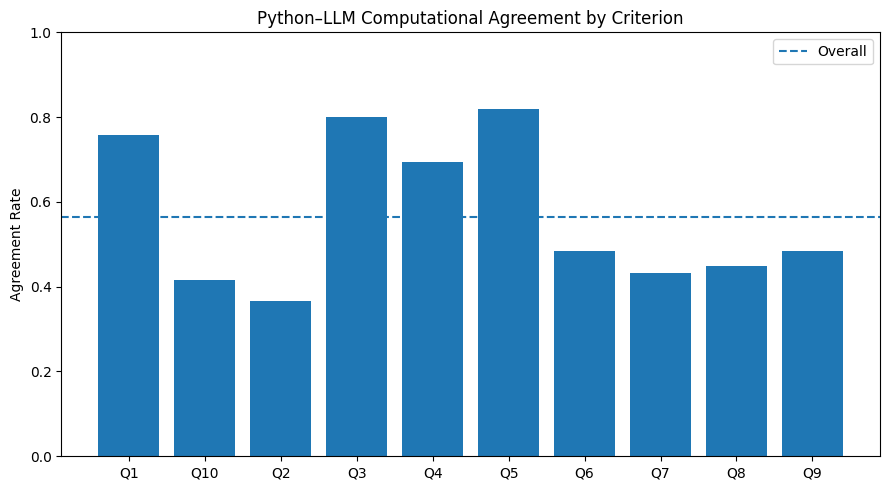

In [ ]:
# ============================================================
# VISUALISE VERSION 1 AGREEMENT BY CRITERION
# ============================================================
fig, ax = plt.subplots(
    figsize=(9, 5)
)


ax.bar(

    agreement_by_q[
        "Criterion"
    ],

    agreement_by_q[
        "Agreement Rate"
    ]

)


ax.axhline(

    overall_agreement,

    linestyle="--",

    label="Overall"
)


ax.set_ylim(
    0,
    1
)


ax.set_ylabel(
    "Agreement Rate"
)


ax.set_title(
    "Python–LLM Computational Agreement by Criterion"
)


ax.legend()


plt.tight_layout()


plt.savefig(

    OUTPUT_DIR
    /
    "agreement_by_criterion.png",

    dpi=200,

    bbox_inches="tight"

)


plt.show()

In [ ]:
# ============================================================
# CREATE VERSION 1 CANDIDATE AND REVIEW STATUS FIELDS
# ============================================================
comparison[
    "Auto Final Candidate"
] = np.where(

    (
        comparison[
            "Human Review Required"
        ]
        == False
    )

    &

    comparison[
        "Python Score"
    ].notna()

    &

    (
        comparison[
            "Python Score"
        ]
        ==
        comparison[
            "LLM Score"
        ]
    ),

    comparison[
        "Python Score"
    ],

    np.nan

)


print(
    "Auto accepted:",
    comparison[
        "Auto Final Candidate"
    ].notna().sum()
)


print(
    "Still need review:",
    comparison[
        "Auto Final Candidate"
    ].isna().sum()
)

Auto accepted: 307
Still need review: 293


In [ ]:
# ============================================================
# CLEAN TEXT BEFORE EXCEL EXPORT
# ============================================================

import re

ILLEGAL_CHARACTERS_RE = re.compile(
    r'[\x00-\x08\x0B\x0C\x0E-\x1F]'
)

def clean_excel_text(value):
    if isinstance(value, str):
        return ILLEGAL_CHARACTERS_RE.sub("", value)
    return value


# Clean every text column before export
for df in [
    criteria_df,
    pdf_audit_df,
    comparison,
    review_queue,
    agreement_by_q
]:
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].map(clean_excel_text)

print("Illegal Excel characters cleaned ✅")

Illegal Excel characters cleaned ✅


In [ ]:
# ============================================================
# EXPORT THE VERSION 1 REVIEW WORKBOOK
# ============================================================
OUTPUT_FILE = (
    OUTPUT_DIR
    /
    "NZTDCI_Python_LLM_Review.xlsx"
)


with pd.ExcelWriter(
    OUTPUT_FILE,
    engine="openpyxl"
) as writer:

    criteria_df.to_excel(
        writer,
        sheet_name="Criteria",
        index=False
    )

    pdf_audit_df.to_excel(
        writer,
        sheet_name="PDF_Audit",
        index=False
    )

    comparison.to_excel(
        writer,
        sheet_name="All_600",
        index=False
    )

    review_queue.to_excel(
        writer,
        sheet_name="Review_Queue",
        index=False
    )

    agreement_by_q.to_excel(
        writer,
        sheet_name="Agreement",
        index=False
    )


print("Saved successfully ✅")
print(OUTPUT_FILE)

Saved successfully ✅
/Users/punch/Downloads/MSc Project /outputs/NZTDCI_Python_LLM_Review.xlsx


## Part 3 — Python Version 2: refined retrieval and robustness checks

In [ ]:
# =========================================================
# PYTHON VERSION 2
# Improved evidence retrieval + stricter criterion scoring
# =========================================================

import re
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import cohen_kappa_score, confusion_matrix
from pypdf import PdfReader

PROJECT_DIR = Path.cwd()

EXCEL_PATH = PROJECT_DIR / "Pilot new.xlsx"

OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

CACHE_PATH = OUTPUT_DIR / "pdf_text_cache.pkl"


print("Project:", PROJECT_DIR)
print("Excel found:", EXCEL_PATH.exists())

Project: /Users/punch/Desktop/MSc Project 
Excel found: True


In [ ]:
# ============================================================
# RELOAD THE THAI CODING SAMPLE FOR VERSION 2
# ============================================================
coding_all = pd.read_excel(
    EXCEL_PATH,
    sheet_name="Coding_800"
)

coding = coding_all[
    coding_all["Type"] == "Thai Main Sample"
].copy()


coding["Year"] = (
    pd.to_numeric(
        coding["Year"],
        errors="coerce"
    )
    .astype(int)
)


coding["LLM Score"] = pd.to_numeric(
    coding["Assistant Proposed Score"],
    errors="coerce"
)


coding["Row_ID"] = (
    coding["Company"].astype(str)
    + "_"
    + coding["Year"].astype(str)
    + "_"
    + coding["Criterion"].astype(str)
)


print("Rows:", len(coding))
print("Companies:", coding["Company"].nunique())
print("Years:", sorted(coding["Year"].unique()))

Rows: 600
Companies: 15
Years: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [ ]:
# ============================================================
# DEFINE VERSION 2 COMPANY ALIASES
# ============================================================
COMPANY_ALIASES = {

    "PTT": ["PTT"],

    "PTTEP": ["PTTEP"],

    "GPSC": ["GPSC"],

    "GULF": ["GULF"],

    "KBANK": [
        "KBANK",
        "KASIKORN"
    ],

    "SCBX": ["SCBX"],

    "SCC": [
        "SCC",
        "SCG"
    ],

    "CP ALL": [
        "CP ALL",
        "CPALL"
    ],

    "CPALL": [
        "CP ALL",
        "CPALL"
    ],

    "CPN": ["CPN"],

    "ADVANC": [
        "ADVANC",
        "AIS"
    ],

    "BCP": [
        "BCP",
        "BANGCHAK"
    ],

    "AOT": ["AOT"],

    "BBL": [
        "BBL",
        "BANGKOK BANK"
    ],

    "DELTA": ["DELTA"],

    "BDMS": ["BDMS"]
}


def normalize_text(text):

    if text is None:
        return ""

    if isinstance(text, float) and np.isnan(text):
        return ""

    text = str(text).lower()

    text = (
        text
        .replace("–", "-")
        .replace("—", "-")
        .replace("\n", " ")
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


def normalize_name(text):

    text = normalize_text(text)

    text = re.sub(
        r"[^a-z0-9]+",
        " ",
        text
    )

    return " ".join(
        text.split()
    )

In [ ]:
# ============================================================
# PREPARE VERSION 2 PDF MATCHING
# ============================================================
ALL_PDFS = list(
    PROJECT_DIR.rglob("*.pdf")
)


def aliases_for_company(company):

    return COMPANY_ALIASES.get(
        str(company).strip(),
        [str(company).strip()]
    )


def pdf_matches_company(
    pdf_path,
    company
):

    path_text = normalize_name(
        str(pdf_path)
    )


    for alias in aliases_for_company(
        company
    ):

        alias = normalize_name(alias)

        if re.search(
            rf"\b{re.escape(alias)}\b",
            path_text
        ):
            return True


    return False


def find_company_year_pdfs(
    company,
    year
):

    year = str(int(year))

    matches = []


    for pdf in ALL_PDFS:

        if not pdf_matches_company(
            pdf,
            company
        ):
            continue

        
        if year not in pdf.name:

            continue


        matches.append(pdf)


    return matches


print("Total PDFs:", len(ALL_PDFS))

Total PDFs: 129


In [ ]:
# ============================================================
# LOAD OR REBUILD THE VERSION 2 PDF CACHE
# ============================================================
if CACHE_PATH.exists():

    try:

        with open(
            CACHE_PATH,
            "rb"
        ) as file:

            PDF_CACHE = pickle.load(
                file
            )

        print(
            "Loaded PDF cache:",
            len(PDF_CACHE)
        )

    except:

        PDF_CACHE = {}

else:

    PDF_CACHE = {}


def extract_pdf_pages(pdf_path):

    key = str(
        pdf_path.resolve()
    )


    
    if key in PDF_CACHE:

        cached = PDF_CACHE[key]

        
        if isinstance(cached, dict):

            if "pages" in cached:
                return cached["pages"]

        if isinstance(cached, list):

            return cached


    pages = []


    try:

        reader = PdfReader(
            str(pdf_path)
        )


        for number, page in enumerate(
            reader.pages,
            start=1
        ):

            try:

                text = (
                    page.extract_text()
                    or ""
                )

            except:

                text = ""


            pages.append({

                "pdf":
                pdf_path,

                "page":
                number,

                "text":
                text

            })


    except Exception as error:

        print(
            "PDF error:",
            pdf_path.name,
            error
        )


    PDF_CACHE[key] = pages


    return pages

Loaded PDF cache: 104


In [ ]:
# ============================================================
# DEFINE VERSION 2 RETRIEVAL KEYWORDS
# ============================================================
V2_KEYWORDS = {

    "Q1": [
        "net zero",
        "net-zero",
        "net zero emissions"
    ],

    "Q2": [
        "emission reduction",
        "emissions reduction",
        "reduce emissions",
        "reduction target",
        "ghg reduction",
        "emissions intensity"
    ],

    "Q3": [
        "sbti",
        "science based targets initiative",
        "science-based targets initiative"
    ],

    "Q4": [
        "scope 1",
        "scope 2"
    ],

    "Q5": [
        "scope 3",
        "financed emissions"
    ],

    "Q6": [
        "scope 1",
        "scope 2",
        "scope 3",
        "ghg emissions",
        "greenhouse gas emissions"
    ],

    "Q7": [
        "transition",
        "net zero",
        "net-zero",
        "decarbonisation",
        "decarbonization",
        "emission reduction",
        "ccs",
        "carbon capture"
    ],

    "Q8": [
        "board of directors",
        "board committee",
        "board-level",
        "sustainability committee"
    ],

    "Q9": [
        "progress",
        "actual performance",
        "performance against",
        "achievement",
        "target"
    ],

    "Q10": [
        "independent assurance",
        "limited assurance",
        "reasonable assurance",
        "external assurance",
        "independent verification"
    ]
}

In [ ]:
# ============================================================
# CREATE EVIDENCE-WINDOW EXTRACTION
# ============================================================
def evidence_windows(
    text,
    keywords,
    window=700
):

    text = re.sub(
        r"\s+",
        " ",
        str(text)
    ).strip()


    lower = text.lower()


    windows = []


    for keyword in keywords:

        for match in re.finditer(
            re.escape(
                keyword.lower()
            ),
            lower
        ):

            start = max(
                0,
                match.start() - window
            )

            end = min(
                len(text),
                match.end() + window
            )


            windows.append(
                text[start:end]
            )


    
    unique = []

    seen = set()


    for item in windows:

        key = item[:250]

        if key not in seen:

            seen.add(key)

            unique.append(item)


    return unique

In [ ]:
# ============================================================
# RETRIEVE EVIDENCE FOR VERSION 2
# ============================================================
def retrieve_v2_evidence(
    company,
    year,
    criterion,
    max_windows=6
):

    pdfs = find_company_year_pdfs(
        company,
        year
    )


    if len(pdfs) == 0:

        return {

            "text": "",

            "display":
            "",

            "sources":
            "",

            "status":
            "NO EXACT-YEAR PDF"

        }


    candidates = []


    for pdf in pdfs:

        pages = extract_pdf_pages(
            pdf
        )


        for page in pages:

            page_text = page["text"]

            if not page_text:

                continue


            windows = evidence_windows(

                page_text,

                V2_KEYWORDS[
                    criterion
                ],

                window=650

            )


            for evidence in windows:

                keyword_hits = sum(

                    1

                    for keyword in V2_KEYWORDS[
                        criterion
                    ]

                    if keyword in evidence.lower()

                )


                candidates.append({

                    "pdf":
                    pdf.name,

                    "page":
                    page["page"],

                    "text":
                    evidence,

                    "keyword_hits":
                    keyword_hits

                })


    if len(candidates) == 0:

        return {

            "text": "",

            "display":
            "",

            "sources":
            " | ".join(
                p.name
                for p in pdfs
            ),

            "status":
            "NO RELEVANT WINDOW"

        }


    candidates = sorted(

        candidates,

        key=lambda x:
        x["keyword_hits"],

        reverse=True

    )


    candidates = candidates[
        :max_windows
    ]


    combined = "\n".join(

        item["text"]

        for item in candidates

    )


    display_text = "\n---\n".join(

        item["text"]

        for item in candidates

    )


    sources = " | ".join(

        f'{item["pdf"]} '
        f'[PDF p.{item["page"]}]'

        for item in candidates

    )


    return {

        "text":
        combined,

        "display":
        display_text,

        "sources":
        sources,

        "status":
        "OK"

    }

In [ ]:
# ============================================================
# DEFINE VERSION 2 TEXT HELPERS
# ============================================================
def find_years(text):

    return sorted(
        set(
            int(year)
            for year in re.findall(
                r"\b20\d{2}\b",
                normalize_text(text)
            )
        )
    )


def find_percentages(text):

    return re.findall(
        r"\b\d+(?:\.\d+)?\s*%",
        normalize_text(text)
    )


def contains_number(text):

    return bool(
        re.search(
            r"\b\d+(?:[,.]\d+)*(?:\.\d+)?\b",
            normalize_text(text)
        )
    )


def contains_ghg_unit(text):

    text = normalize_text(text)

    return any(

        unit in text

        for unit in [

            "tco2e",

            "tco2",

            "mtco2e",

            "kgco2e",

            "co2 equivalent",

            "tonnes co2",

            "tons co2"

        ]

    )


def near_each_other(
    text,
    terms_a,
    terms_b,
    max_distance=600
):

    text = normalize_text(text)


    positions_a = []

    positions_b = []


    for term in terms_a:

        positions_a += [

            match.start()

            for match in re.finditer(
                re.escape(term),
                text
            )

        ]


    for term in terms_b:

        positions_b += [

            match.start()

            for match in re.finditer(
                re.escape(term),
                text
            )

        ]


    for a in positions_a:

        for b in positions_b:

            if abs(a - b) <= max_distance:

                return True


    return False

In [ ]:
# ============================================================
# DEFINE VERSION 2 SCORING FOR Q1
# ============================================================
def score_q1_v2(text):

    text = normalize_text(text)


    patterns = [

        r"net[\s-]?zero(?: emissions)?"
        r".{0,250}"
        r"\b20\d{2}\b",

        r"\b20\d{2}\b"
        r".{0,250}"
        r"net[\s-]?zero"

    ]


    if any(
        re.search(pattern, text)
        for pattern in patterns
    ):

        return (
            1,
            "HIGH",
            "Explicit net-zero wording and target year found in same evidence window"
        )


    return (
        0,
        "MEDIUM",
        "No explicit time-bound net-zero target found"
    )

In [ ]:
# ============================================================
# DEFINE VERSION 2 SCORING FOR Q2
# ============================================================
def score_q2_v2(
    text,
    observation_year
):

    text = normalize_text(text)


    years = find_years(
        text
    )


    percentages = find_percentages(
        text
    )


    reduction = any(

        term in text

        for term in [

            "reduce",

            "reduction",

            "decrease",

            "cut emissions",

            "emissions intensity"

        ]

    )


    target_years = [

        year

        for year in years

        if (
            year >
            observation_year
            and
            year < 2050
        )

    ]


    baseline_year = bool(

        re.search(

            r"(?:baseline|base year|reference year|from)"
            r".{0,40}"
            r"\b20\d{2}\b",

            text

        )

    )


    if (
        reduction
        and
        len(percentages) > 0
        and
        len(target_years) > 0
        and
        baseline_year
    ):

        return (
            1,
            "HIGH",
            "Reduction magnitude + interim year + baseline/reference detected"
        )


    return (
        0,
        "MEDIUM",
        "All three strict interim-target elements were not found together"
    )

In [ ]:
# ============================================================
# DEFINE VERSION 2 SCORING FOR Q3
# ============================================================
def score_q3_v2(
    text,
    observation_year
):

    text = normalize_text(text)


    sbti = (

        "sbti" in text

        or

        "science based targets initiative"
        in text

        or

        "science-based targets initiative"
        in text

    )


    strong_validation = any(

        phrase in text

        for phrase in [

            "validated by sbti",

            "validated by the science based targets initiative",

            "targets have been validated",

            "target has been validated",

            "approved by sbti",

            "sbti-validated",

            "sbti validated"

        ]

    )


    weak_only = any(

        phrase in text

        for phrase in [

            "committed to sbti",

            "commitment to sbti",

            "submitted to sbti",

            "pending validation",

            "seeking validation",

            "plans to submit"

        ]

    )


    if (
        sbti
        and
        strong_validation
        and
        not weak_only
    ):

        return (
            1,
            "MEDIUM",
            "Explicit SBTi validation found in observation-year evidence; historical validation still flagged"
        )


    return (
        0,
        "MEDIUM",
        "No sufficiently explicit year-applicable SBTi validation found"
    )

In [ ]:
# ============================================================
# DEFINE VERSION 2 SCORING FOR Q4
# ============================================================
def score_q4_v2(text):

    text = normalize_text(text)


    scope1_windows = evidence_windows(
        text,
        ["scope 1"],
        window=250
    )


    scope2_windows = evidence_windows(
        text,
        ["scope 2"],
        window=250
    )


    q1_numeric = any(
        contains_number(x)
        and contains_ghg_unit(x)
        for x in scope1_windows
    )


    q2_numeric = any(
        contains_number(x)
        and contains_ghg_unit(x)
        for x in scope2_windows
    )


    if (
        q1_numeric
        and
        q2_numeric
    ):

        return (
            1,
            "HIGH",
            "Numerical Scope 1 and Scope 2 evidence with GHG unit found"
        )


    return (
        0,
        "MEDIUM",
        "Both quantitative Scope 1 and Scope 2 were not confirmed"
    )

In [ ]:
# ============================================================
# DEFINE VERSION 2 SCORING FOR Q5
# ============================================================
def score_q5_v2(text):

    text = normalize_text(text)


    windows = evidence_windows(

        text,

        [
            "scope 3",
            "financed emissions"
        ],

        window=300

    )


    valid = any(

        contains_number(window)
        and
        contains_ghg_unit(window)

        for window in windows

    )


    if valid:

        return (
            1,
            "HIGH",
            "Quantitative Scope 3 / financed emissions found"
        )


    return (
        0,
        "MEDIUM",
        "No quantitative Scope 3 disclosure confirmed"
    )

In [ ]:
# ============================================================
# DEFINE VERSION 2 SCORING FOR Q6
# ============================================================
def score_q6_v2(
    text,
    observation_year
):

    text = normalize_text(text)


    years = [

        year

        for year in find_years(text)

        if year <= observation_year

    ]


    emissions_context = any(

        term in text

        for term in [

            "scope 1",

            "scope 2",

            "scope 3",

            "ghg emissions",

            "greenhouse gas emissions",

            "co2e"

        ]

    )


    if (
        len(set(years)) >= 2
        and
        emissions_context
        and
        contains_number(text)
    ):

        return (
            1,
            "MEDIUM",
            f"At least two historical reporting years detected: {sorted(set(years))}"
        )


    return (
        0,
        "MEDIUM",
        "No clear comparable two-year emissions series"
    )

In [ ]:
# ============================================================
# DEFINE VERSION 2 SCORING FOR Q7
# ============================================================
def score_q7_v2(text):

    text = normalize_text(text)


    transition_terms = [

        "transition plan",

        "climate transition",

        "net zero",

        "net-zero",

        "decarbonisation",

        "decarbonization",

        "emission reduction",

        "carbon capture",

        "ccs"

    ]


    resource_terms = [

        "investment",

        "invest",

        "capex",

        "capital expenditure",

        "budget",

        "financing",

        "million",

        "billion",

        "thb",

        "usd",

        "mw",

        "gw",

        "internal carbon price"

    ]


    measurable_resource = bool(

        re.search(

            r"(?:thb|usd|baht|\$)"
            r"\s*[\d,.]+"

            r"|"

            r"[\d,.]+\s*"
            r"(?:million|billion|mw|gw)",

            text

        )

    )


    explicit_link = near_each_other(

        text,

        transition_terms,

        resource_terms,

        max_distance=500

    )


    if (
        measurable_resource
        and
        explicit_link
    ):

        return (
            1,
            "LOW",
            "Measurable resource appears explicitly linked to transition/decarbonisation evidence; manual high-priority check retained"
        )


    return (
        0,
        "MEDIUM",
        "No sufficiently explicit transition-plan/resource linkage"
    )

In [ ]:
# ============================================================
# DEFINE VERSION 2 SCORING FOR Q8
# ============================================================
def score_q8_v2(text):

    text = normalize_text(text)


    board_terms = [

        "board of directors",

        "board committee",

        "board-level",

        "sustainability committee",

        "corporate governance and sustainability committee"

    ]


    oversight_terms = [

        "oversight",

        "oversee",

        "responsibility",

        "responsible",

        "supervise",

        "monitor",

        "review",

        "approve"

    ]


    climate_terms = [

        "climate",

        "net zero",

        "net-zero",

        "sustainability",

        "esg",

        "greenhouse gas"

    ]


    board_climate = near_each_other(

        text,

        board_terms,

        climate_terms,

        500

    )


    board_oversight = near_each_other(

        text,

        board_terms,

        oversight_terms,

        500

    )


    if (
        board_climate
        and
        board_oversight
    ):

        return (
            1,
            "MEDIUM",
            "Board-level body, oversight responsibility and climate/sustainability context found together"
        )


    return (
        0,
        "MEDIUM",
        "No explicit board-level climate oversight confirmed"
    )

In [ ]:
# ============================================================
# DEFINE VERSION 2 SCORING FOR Q9
# ============================================================
def score_q9_v2(text):

    text = normalize_text(text)


    performance_terms = [

        "actual",

        "achieved",

        "achievement",

        "progress",

        "performance",

        "reduced",

        "reduction"

    ]


    comparison_terms = [

        "target",

        "baseline",

        "against",

        "compared with",

        "compared to",

        "previous year",

        "prior year",

        "pathway"

    ]


    linked = near_each_other(

        text,

        performance_terms,

        comparison_terms,

        max_distance=500

    )


    quantitative = (

        len(find_percentages(text)) > 0

        or

        contains_number(text)

    )


    if (
        linked
        and
        quantitative
    ):

        return (
            1,
            "MEDIUM",
            "Quantitative actual/progress and target/baseline comparator found together"
        )


    return (
        0,
        "MEDIUM",
        "No measurable progress-against-target evidence confirmed"
    )

In [ ]:
# ============================================================
# DEFINE VERSION 2 SCORING FOR Q10
# ============================================================
def score_q10_v2(text):

    text = normalize_text(text)


    assurance_terms = [

        "independent assurance",

        "limited assurance",

        "reasonable assurance",

        "external assurance",

        "independent verification",

        "third-party verification",

        "third party verification"

    ]


    sustainability_terms = [

        "greenhouse gas",

        "ghg",

        "emissions",

        "scope 1",

        "scope 2",

        "scope 3",

        "sustainability",

        "climate"

    ]


    linked = near_each_other(

        text,

        assurance_terms,

        sustainability_terms,

        max_distance=600

    )


    if linked:

        return (
            1,
            "MEDIUM",
            "Independent assurance and relevant sustainability/GHG coverage detected together"
        )


    return (
        0,
        "MEDIUM",
        "No relevant independent external assurance confirmed"
    )

In [ ]:
# ============================================================
# ROUTE EVIDENCE TO THE CORRECT VERSION 2 SCORING RULE
# ============================================================
def python_v2_score(
    criterion,
    text,
    year,
    status
):

    if (
        status != "OK"
        or
        len(normalize_text(text)) < 30
    ):

        return (
            np.nan,
            "LOW",
            "Insufficient machine-readable evidence"
        )


    if criterion == "Q1":

        return score_q1_v2(
            text
        )


    elif criterion == "Q2":

        return score_q2_v2(
            text,
            year
        )


    elif criterion == "Q3":

        return score_q3_v2(
            text,
            year
        )


    elif criterion == "Q4":

        return score_q4_v2(
            text
        )


    elif criterion == "Q5":

        return score_q5_v2(
            text
        )


    elif criterion == "Q6":

        return score_q6_v2(
            text,
            year
        )


    elif criterion == "Q7":

        return score_q7_v2(
            text
        )


    elif criterion == "Q8":

        return score_q8_v2(
            text
        )


    elif criterion == "Q9":

        return score_q9_v2(
            text
        )


    elif criterion == "Q10":

        return score_q10_v2(
            text
        )


    return (
        np.nan,
        "LOW",
        "Unknown criterion"
    )

In [ ]:
# ============================================================
# RUN VERSION 2 SCORING ACROSS ALL THAI OBSERVATIONS
# ============================================================
v2_results = []


total = len(coding)


for number, (_, row) in enumerate(
    coding.iterrows(),
    start=1
):

    evidence = retrieve_v2_evidence(

        row["Company"],

        row["Year"],

        row["Criterion"]

    )


    score, confidence, reason = python_v2_score(

        row["Criterion"],

        evidence["text"],

        row["Year"],

        evidence["status"]

    )


    v2_results.append({

        "Row_ID":
        row["Row_ID"],

        "Python V2 Score":
        score,

        "Python V2 Confidence":
        confidence,

        "Python V2 Reason":
        reason,

        "Python V2 Evidence":
        evidence["display"],

        "Python V2 Source":
        evidence["sources"],

        "Python V2 Status":
        evidence["status"]

    })


    if number % 50 == 0:

        print(
            f"Processed V2 "
            f"{number}/{total}"
        )


v2_results = pd.DataFrame(
    v2_results
)


print("V2 DONE")

Processed V2 50/600
Processed V2 100/600


Ignoring wrong pointing object 100 0 (offset 0)
Ignoring wrong pointing object 101 0 (offset 0)
Ignoring wrong pointing object 89 0 (offset 0)
Ignoring wrong pointing object 90 0 (offset 0)
Ignoring wrong pointing object 95 0 (offset 0)
Ignoring wrong pointing object 96 0 (offset 0)


Processed V2 150/600


Ignoring wrong pointing object 94 0 (offset 0)
Ignoring wrong pointing object 95 0 (offset 0)
Object 60709 0 not defined.
Object 60717 0 not defined.
Object 60722 0 not defined.
Object 60727 0 not defined.
Object 60732 0 not defined.
Object 60737 0 not defined.
Object 60742 0 not defined.
Object 60747 0 not defined.
Object 60794 0 not defined.
Object 60836 0 not defined.
Object 60910 0 not defined.
Object 60921 0 not defined.
Object 60971 0 not defined.
Object 60982 0 not defined.
Object 60989 0 not defined.
Object 60994 0 not defined.
Object 61002 0 not defined.
Object 61024 0 not defined.
Object 24263 0 not defined.
Object 24301 0 not defined.
Object 24876 0 not defined.
Object 24881 0 not defined.
Object 24886 0 not defined.
Object 24891 0 not defined.
Object 24902 0 not defined.
Object 24907 0 not defined.
Object 24936 0 not defined.
Object 27504 0 not defined.
Object 27515 0 not defined.
Object 27562 0 not defined.
Object 27708 0 not defined.
Object 27734 0 not defined.
Object 277

Processed V2 200/600
Processed V2 250/600


...

Processed V2 300/600


Ignoring wrong pointing object 23 0 (offset 0)
Ignoring wrong pointing object 28 0 (offset 0)
Ignoring wrong pointing object 77 0 (offset 0)


Processed V2 350/600
Processed V2 400/600
Processed V2 450/600
Processed V2 500/600


Ignoring wrong pointing object 1805 0 (offset 0)
Ignoring wrong pointing object 6625 0 (offset 0)


Processed V2 550/600
Processed V2 600/600
V2 DONE


In [ ]:
# ============================================================
# MERGE VERSION 2 RESULTS WITH THE PRELIMINARY CODING
# ============================================================
v2_comparison = coding.merge(

    v2_results,

    on="Row_ID",

    how="left"

)


v2_comparison[
    "Python V2 Score"
] = pd.to_numeric(

    v2_comparison[
        "Python V2 Score"
    ],

    errors="coerce"

)


v2_comparison[
    "V2 Agreement"
] = np.where(

    v2_comparison[
        "Python V2 Score"
    ].notna(),

    (
        v2_comparison[
            "Python V2 Score"
        ]

        ==

        v2_comparison[
            "LLM Score"
        ]
    ),

    np.nan

)

In [ ]:
# ============================================================
# CALCULATE OVERALL VERSION 2 AGREEMENT
# ============================================================
valid_v2 = v2_comparison.dropna(

    subset=[
        "Python V2 Score",
        "LLM Score"
    ]

).copy()


valid_v2[
    "Python V2 Score"
] = valid_v2[
    "Python V2 Score"
].astype(int)


valid_v2[
    "LLM Score"
] = valid_v2[
    "LLM Score"
].astype(int)


v2_overall_agreement = (

    valid_v2[
        "Python V2 Score"
    ]

    ==

    valid_v2[
        "LLM Score"
    ]

).mean()


v2_kappa = cohen_kappa_score(

    valid_v2[
        "Python V2 Score"
    ],

    valid_v2[
        "LLM Score"
    ]

)


print(
    "V2 Overall Agreement:",
    round(
        v2_overall_agreement,
        3
    )
)


print(
    "V2 Kappa:",
    round(
        v2_kappa,
        3
    )
)

V2 Overall Agreement: 0.535
V2 Kappa: 0.077


In [ ]:
# ============================================================
# CALCULATE CRITERION-LEVEL VERSION 2 AGREEMENT
# ============================================================
v2_agreement_rows = []


for criterion in sorted(

    valid_v2[
        "Criterion"
    ].unique(),

    key=lambda x:
    int(
        x.replace(
            "Q",
            ""
        )
    )

):

    subset = valid_v2[

        valid_v2[
            "Criterion"
        ]
        ==
        criterion

    ]


    agreement = (

        subset[
            "Python V2 Score"
        ]

        ==

        subset[
            "LLM Score"
        ]

    ).mean()


    try:

        kappa = cohen_kappa_score(

            subset[
                "Python V2 Score"
            ],

            subset[
                "LLM Score"
            ]

        )

    except:

        kappa = np.nan


    v2_agreement_rows.append({

        "Criterion":
        criterion,

        "N":
        len(subset),

        "V2 Agreement Rate":
        agreement,

        "V2 Kappa":
        kappa

    })


v2_agreement_df = pd.DataFrame(
    v2_agreement_rows
)


display(
    v2_agreement_df
)

,Criterion,N,V2 Agreement Rate,V2 Kappa
0,Q1,58,0.775862,0.232179
1,Q2,57,0.543860,0.008032
2,Q3,30,0.833333,0.594595
3,Q4,55,0.490909,-0.029412
4,Q5,48,0.583333,-0.019108
5,Q6,60,0.516667,0.093750
6,Q7,59,0.508475,-0.083597
7,Q8,60,0.500000,0.137931
8,Q9,60,0.450000,-0.066810
9,Q10,59,0.305085,0.029683


In [ ]:
# ============================================================
# CREATE VERSION 2 REVIEW REASONS
# ============================================================
def v2_review_reason(row):

    reasons = []


    score = row[
        "Python V2 Score"
    ]


    llm = row[
        "LLM Score"
    ]


    q = row[
        "Criterion"
    ]


    priority = "NONE"


    if pd.isna(score):

        reasons.append(
            "Python V2 unable to score"
        )

        priority = "HIGH"


    elif score != llm:

        reasons.append(
            "Python V2–LLM disagreement"
        )

        priority = "HIGH"


    # SBTi
    if (
        q == "Q3"
        and
        (
            score == 1
            or
            llm == 1
        )
    ):

        reasons.append(
            "Historical SBTi validation check"
        )

        priority = "CRITICAL"


    # Resource allocation
    if (
        q == "Q7"
        and
        (
            score == 1
            or
            llm == 1
        )
    ):

        reasons.append(
            "Explicit Q7 transition-resource linkage check"
        )

        priority = "CRITICAL"


    if (
        row[
            "Python V2 Confidence"
        ]
        == "LOW"
    ):

        reasons.append(
            "Low Python V2 confidence"
        )

        if priority == "NONE":

            priority = "MEDIUM"


    if (
        row[
            "Python V2 Status"
        ]
        != "OK"
    ):

        reasons.append(
            row[
                "Python V2 Status"
            ]
        )

        if priority == "NONE":

            priority = "MEDIUM"


    return pd.Series({

        "V2 Review Reason":
        "; ".join(
            dict.fromkeys(
                reasons
            )
        ),

        "V2 Review Priority":
        priority

    })


v2_comparison[
    [
        "V2 Review Reason",
        "V2 Review Priority"
    ]
] = v2_comparison.apply(

    v2_review_reason,

    axis=1

)

In [ ]:
# ============================================================
# BUILD THE VERSION 2 REVIEW QUEUE
# ============================================================
v2_review_queue = v2_comparison[

    v2_comparison[
        "V2 Review Priority"
    ]
    != "NONE"

].copy()


v2_review_queue[
    "Human Final Score"
] = np.nan


v2_review_queue[
    "Human Review Note"
] = ""


print(
    "Total rows:",
    len(v2_comparison)
)


print(
    "Need review:",
    len(v2_review_queue)
)


print(
    "Review %:",
    round(
        len(v2_review_queue)
        /
        len(v2_comparison)
        *
        100,
        1
    )
)


print("\nPriority:")

print(

    v2_review_queue[
        "V2 Review Priority"
    ].value_counts()

)

Total rows: 600
Need review: 320
Review %: 53.3

Priority:
V2 Review Priority
HIGH        268
CRITICAL     52
Name: count, dtype: int64


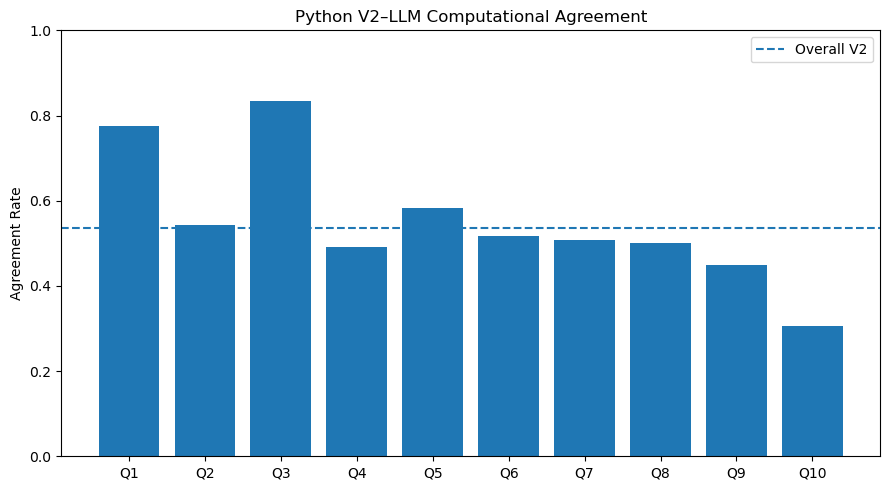

In [ ]:
# ============================================================
# VISUALISE VERSION 2 AGREEMENT
# ============================================================
fig, ax = plt.subplots(
    figsize=(9, 5)
)


ax.bar(

    v2_agreement_df[
        "Criterion"
    ],

    v2_agreement_df[
        "V2 Agreement Rate"
    ]

)


ax.axhline(

    v2_overall_agreement,

    linestyle="--",

    label="Overall V2"

)


ax.set_ylim(
    0,
    1
)


ax.set_ylabel(
    "Agreement Rate"
)


ax.set_title(
    "Python V2–LLM Computational Agreement"
)


ax.legend()


plt.tight_layout()


plt.savefig(

    OUTPUT_DIR
    /
    "V2_Agreement_by_Criterion.png",

    dpi=200,

    bbox_inches="tight"

)


plt.show()

In [ ]:
# ============================================================
# CLEAN VERSION 2 TEXT FOR EXCEL
# ============================================================
ILLEGAL_CHARACTERS_RE = re.compile(
    r'[\x00-\x08\x0B\x0C\x0E-\x1F]'
)


def clean_excel_text(value):

    if isinstance(
        value,
        str
    ):

        return ILLEGAL_CHARACTERS_RE.sub(
            "",
            value
        )


    return value


for dataframe in [

    v2_comparison,

    v2_review_queue,

    v2_agreement_df

]:

    for column in dataframe.columns:

        if (
            dataframe[
                column
            ].dtype
            ==
            "object"
        ):

            dataframe[
                column
            ] = dataframe[
                column
            ].map(
                clean_excel_text
            )


print(
    "V2 Excel text cleaned"
)

V2 Excel text cleaned


In [ ]:
# ============================================================
# EXPORT THE VERSION 2 REVIEW WORKBOOK
# ============================================================
V2_OUTPUT_FILE = (

    OUTPUT_DIR
    /
    "NZTDCI_Python_V2_LLM_Review.xlsx"

)


with pd.ExcelWriter(

    V2_OUTPUT_FILE,

    engine="openpyxl"

) as writer:


    v2_comparison.to_excel(

        writer,

        sheet_name="All_600_V2",

        index=False

    )


    v2_review_queue.to_excel(

        writer,

        sheet_name="Review_Queue_V2",

        index=False

    )


    v2_agreement_df.to_excel(

        writer,

        sheet_name="Agreement_V2",

        index=False

    )


print(
    "Saved successfully:"
)


print(
    V2_OUTPUT_FILE
)

Saved successfully:
/Users/punch/Desktop/MSc Project /outputs/NZTDCI_Python_V2_LLM_Review.xlsx


## Part 4 — Blind structured second-pass preparation

In [ ]:
# ============================================================
# FREEZE THE FINAL Q1–Q10 RULES FOR THE BLIND SECOND PASS
# ============================================================
CRITERIA = {

    "Q1": {
        "name": "Time-Bound Net-Zero Target",
        "score_1": "Explicit company-level net-zero target AND a specific target year.",
        "score_0": "Generic climate ambition, national target, carbon-neutrality only, or no explicit company net-zero target year."
    },

    "Q2": {
        "name": "Measurable Interim Emissions-Reduction Target",
        "score_1": "Quantitative interim emissions-reduction target with magnitude, target year, and baseline/reference year.",
        "score_0": "Qualitative or incomplete target, or missing magnitude, target year, or baseline/reference point."
    },

    "Q3": {
        "name": "SBTi-Validated Target",
        "score_1": "Official SBTi validation applies to the observation year; validation must already exist by that reporting year.",
        "score_0": "Committed, aligned, submitted, pending, or validation occurred only in a later year."
    },

    "Q4": {
        "name": "Quantitative Scope 1 and Scope 2 Disclosure",
        "score_1": "Numerical Scope 1 AND numerical Scope 2 greenhouse-gas emissions with relevant units.",
        "score_0": "Only one scope is quantitative or disclosure is qualitative only."
    },

    "Q5": {
        "name": "Quantitative Scope 3 Disclosure",
        "score_1": "Numerical Scope 3 emissions are disclosed; quantitative financed emissions may qualify for financial institutions.",
        "score_0": "Scope 3 is discussed without quantitative disclosure."
    },

    "Q6": {
        "name": "Comparable Multi-Year Emissions Data",
        "score_1": "At least two historical years of comparable quantitative emissions data.",
        "score_0": "Single-year data or materially non-comparable data."
    },

    "Q7": {
        "name": "Transition Implementation & Resource Allocation",
        "score_1": "Concrete transition action AND measurable financial or operational resources explicitly linked to the firm's net-zero, decarbonisation, or climate-transition plan/target.",
        "score_0": "Generic CAPEX, green finance, renewable activity, or sustainability spending without explicit transition-plan/target linkage."
    },

    "Q8": {
        "name": "Board-Level Climate Oversight",
        "score_1": "Board or board-level committee explicitly oversees climate, net-zero, ESG, or sustainability matters.",
        "score_0": "Management-only responsibility or no explicit board-level oversight."
    },

    "Q9": {
        "name": "Measurable Progress Against Targets",
        "score_1": "Quantitative actual performance is compared with a target, baseline, pathway, or prior-period benchmark.",
        "score_0": "No measurable progress comparison."
    },

    "Q10": {
        "name": "Independent External Assurance",
        "score_1": "Independent external assurance or verification covers relevant GHG, emissions, climate, or sustainability information.",
        "score_0": "Financial-statement audit only or no relevant sustainability/GHG assurance."
    }
}

print("CRITERIA loaded:", len(CRITERIA))

CRITERIA loaded: 10


In [33]:
# ============================================================
# STRUCTURED LLM SECOND PASS
# Create a BLIND evidence pack
# ============================================================

blind_pack = v2_comparison[
    [
        "Row_ID",
        "Company",
        "Year",
        "Criterion",
        "Criterion Name",
        "Python V2 Evidence",
        "Python V2 Source"
    ]
].copy()


blind_pack["Score 1 Rule"] = blind_pack["Criterion"].map(
    lambda q: CRITERIA[q]["score_1"].strip()
)

blind_pack["Score 0 Rule"] = blind_pack["Criterion"].map(
    lambda q: CRITERIA[q]["score_0"].strip()
)


blind_pack["LLM Run 2 Score"] = np.nan
blind_pack["LLM Run 2 Confidence"] = ""
blind_pack["LLM Run 2 Rationale"] = ""
blind_pack["Evidence Sufficient?"] = ""


display(blind_pack.head())
print("Blind rows:", len(blind_pack))

,Row_ID,Company,Year,Criterion,Criterion Name,Python V2 Evidence,Python V2 Source,Score 1 Rule,Score 0 Rule,LLM Run 2 Score,LLM Run 2 Confidence,LLM Run 2 Rationale,Evidence Sufficient?
0,PTT_2022_Q1,PTT,2022,Q1,Time-Bound Net-Zero Target,"the COVID-19 situation. • Awarded March 31, 20...",PTT one report 2022.pdf [PDF p.11] | PTT one r...,Explicit company-level net-zero target AND a s...,"Generic climate ambition, national target, car...",NaN,,,
1,PTT_2022_Q2,PTT,2022,Q2,Measurable Interim Emissions-Reduction Target,up received an honorary award under “Zero Acci...,PTT one report 2022.pdf [PDF p.11] | PTT one r...,Quantitative interim emissions-reduction targe...,"Qualitative or incomplete target, or missing m...",NaN,,,
2,PTT_2022_Q3,PTT,2022,Q3,SBTi-Validated Target,,PTT one report 2022.pdf,Official SBTi validation applies to the observ...,"Committed, aligned, submitted, pending, or val...",NaN,,,
3,PTT_2022_Q4,PTT,2022,Q4,Quantitative Scope 1 and Scope 2 Disclosure,"t aat em en t”, as signed b y Pres ident & CEO...",PTT one report 2022.pdf [PDF p.69] | PTT one r...,Numerical Scope 1 AND numerical Scope 2 greenh...,Only one scope is quantitative or disclosure i...,NaN,,,
4,PTT_2022_Q5,PTT,2022,Q5,Quantitative Scope 3 Disclosure,ertiﬁ cation for compressed bio-methane gas de...,PTT one report 2022.pdf [PDF p.84] | PTT one r...,Numerical Scope 3 emissions are disclosed; qua...,Scope 3 is discussed without quantitative disc...,NaN,,,


Blind rows: 600


In [ ]:
# ============================================================
# DEFINE BLIND SECOND-PASS SCORING INSTRUCTIONS
# ============================================================
SCORING_INSTRUCTION = """
You are conducting a structured content-analysis coding exercise.

For each row:

1. Assess ONLY the evidence supplied.
2. Apply the Score 1 Rule and Score 0 Rule strictly.
3. Do not infer information that is not explicitly supported.
4. Score only 0 or 1.
5. If the evidence is insufficient, record:
   Score = 0
   Evidence Sufficient? = No
6. For Q3:
   SBTi validation must apply to that observation year.
   A later validation cannot be back-cast.
7. For Q7:
   Generic CAPEX, investment, renewable activity or green financing
   does NOT qualify unless resources are explicitly connected to the
   firm's transition/net-zero/decarbonisation plan or target.
8. Provide a short rationale explaining the decision.

Do not use or attempt to infer any previous coding score.
"""

In [ ]:
# ============================================================
# CLEAN BLIND-PACK VALUES FOR EXCEL
# ============================================================
ILLEGAL_CHARACTERS_RE = re.compile(
    r'[\x00-\x08\x0B\x0C\x0E-\x1F]'
)


def clean_excel_value(value):

    if isinstance(value, str):

        return ILLEGAL_CHARACTERS_RE.sub(
            "",
            value
        )

    return value


for column in blind_pack.columns:

    if blind_pack[column].dtype == "object":

        blind_pack[column] = blind_pack[column].map(
            clean_excel_value
        )

In [ ]:
# ============================================================
# CREATE THE CRITERIA REFERENCE TABLE
# ============================================================
criteria_df = pd.DataFrame(
    [
        {
            "Criterion": q,
            "Name": rule["name"],
            "Score 1 Rule": rule["score_1"],
            "Score 0 Rule": rule["score_0"]
        }
        for q, rule in CRITERIA.items()
    ]
)

display(criteria_df)

print("criteria_df created:", len(criteria_df), "rows")

,Criterion,Name,Score 1 Rule,Score 0 Rule
0,Q1,Time-Bound Net-Zero Target,Explicit company-level net-zero target AND a s...,"Generic climate ambition, national target, car..."
1,Q2,Measurable Interim Emissions-Reduction Target,Quantitative interim emissions-reduction targe...,"Qualitative or incomplete target, or missing m..."
2,Q3,SBTi-Validated Target,Official SBTi validation applies to the observ...,"Committed, aligned, submitted, pending, or val..."
3,Q4,Quantitative Scope 1 and Scope 2 Disclosure,Numerical Scope 1 AND numerical Scope 2 greenh...,Only one scope is quantitative or disclosure i...
4,Q5,Quantitative Scope 3 Disclosure,Numerical Scope 3 emissions are disclosed; qua...,Scope 3 is discussed without quantitative disc...
5,Q6,Comparable Multi-Year Emissions Data,At least two historical years of comparable qu...,Single-year data or materially non-comparable ...
6,Q7,Transition Implementation & Resource Allocation,Concrete transition action AND measurable fina...,"Generic CAPEX, green finance, renewable activi..."
7,Q8,Board-Level Climate Oversight,Board or board-level committee explicitly over...,Management-only responsibility or no explicit ...
8,Q9,Measurable Progress Against Targets,Quantitative actual performance is compared wi...,No measurable progress comparison.
9,Q10,Independent External Assurance,Independent external assurance or verification...,Financial-statement audit only or no relevant ...


criteria_df created: 10 rows


In [ ]:
# ============================================================
# CHECK REQUIRED BLIND-PACK OBJECTS
# ============================================================
print("blind_pack:", "blind_pack" in globals())
print("SCORING_INSTRUCTION:", "SCORING_INSTRUCTION" in globals())
print("criteria_df:", "criteria_df" in globals())
print("OUTPUT_DIR:", "OUTPUT_DIR" in globals())

blind_pack: True
SCORING_INSTRUCTION: True
criteria_df: True
OUTPUT_DIR: True


In [ ]:
# ============================================================
# EXPORT THE BLIND SECOND-PASS WORKBOOK
# ============================================================
BLIND_OUTPUT = (
    OUTPUT_DIR
    / "NZTDCI_Blind_LLM_Run2_Pack.xlsx"
)

with pd.ExcelWriter(
    BLIND_OUTPUT,
    engine="openpyxl"
) as writer:

    blind_pack.to_excel(
        writer,
        sheet_name="Blind_Coding",
        index=False
    )

    pd.DataFrame({
        "Instruction": [SCORING_INSTRUCTION]
    }).to_excel(
        writer,
        sheet_name="Instructions",
        index=False
    )

    criteria_df.to_excel(
        writer,
        sheet_name="Criteria",
        index=False
    )

print("Saved successfully ✅")
print(BLIND_OUTPUT)

Saved successfully ✅
/Users/punch/Desktop/MSc Project /outputs/NZTDCI_Blind_LLM_Run2_Pack.xlsx


# Part 5 — Final Statistical Analysis and Regression

In [40]:
# ============================================================
# INSTALL AND IMPORT STATISTICAL PACKAGES
# ============================================================
%pip -q install linearmodels openpyxl

from pathlib import Path
import sys
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

from linearmodels.panel import PanelOLS, RandomEffects

print("Statistical packages loaded successfully.")
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("statsmodels:", statsmodels.__version__)


Note: you may need to restart the kernel to use updated packages.
Statistical packages loaded successfully.
Python: 3.13.5
pandas: 2.2.3
numpy: 2.1.3
statsmodels: 0.14.4


In [41]:
# ============================================================
# LOAD THE FINAL APPROVED EXCEL DATASET
# ============================================================
FINAL_FILE = Path("/Users/punch/Desktop/MSc Project /NZTDCI pre regression combine.xlsx")

if not FINAL_FILE.exists():
    raise FileNotFoundError(
        "The final Excel file was not found. "
        "Place NZTDCI_Regression_Ready_Master.xlsx in the same folder "
        "as this notebook or change FINAL_FILE to the correct filename."
    )

financial_raw = pd.read_excel(
    FINAL_FILE,
    sheet_name="Financial_Data_Thai"
)

coding_raw = pd.read_excel(
    FINAL_FILE,
    sheet_name="Coding_Final"
)

print("Final workbook loaded:", FINAL_FILE.name)
print("Financial dataset shape:", financial_raw.shape)
print("Coding dataset shape:", coding_raw.shape)

display(financial_raw.head())


Final workbook loaded: NZTDCI pre regression combine.xlsx
Financial dataset shape: (60, 20)
Coding dataset shape: (800, 14)


,Company,Year,Sector,Net Income (THB mn),Total Assets (THB mn),Prior-Year Assets (THB mn),Average Assets (THB mn),Total Equity (THB mn),Prior-Year Equity (THB mn),Average Equity (THB mn),Total Liabilities (THB mn),Revenue (THB mn),ROA,ROE,ln(Total Assets),Leverage,Final NZTDCI /100,Financial Source,Source-file audit trail,Regression Status
0,PTT,2022,Energy,91174.86,3415632.29,3078018.83,3246825.560,1052590.88,1006696.22,1029643.550,1881939.53,3391622.87,0.028081,0.088550,15.043873,0.550978,80,Stock Exchange of Thailand (SET) — financial d...,Source files retained separately,Ready to run
1,PTT,2023,Energy,112023.88,3460461.90,3415632.29,3438047.095,1121197.88,1052590.88,1086894.380,1835486.49,3185256.08,0.032584,0.103068,15.056913,0.530417,60,Stock Exchange of Thailand (SET) — financial d...,Source files retained separately,Ready to run
2,PTT,2024,Energy,90072.08,3438784.28,3460461.90,3449623.090,1149652.17,1121197.88,1135425.025,1781907.19,3138378.01,0.026111,0.079329,15.050629,0.518179,70,Stock Exchange of Thailand (SET) — financial d...,Source files retained separately,Ready to run
3,PTT,2025,Energy,90166.37,3269659.98,3438784.28,3354222.130,1127422.10,1149652.17,1138537.135,1617176.37,2707981.66,0.026881,0.079195,15.000197,0.494601,80,Stock Exchange of Thailand (SET) — financial d...,Source files retained separately,Ready to run
4,PTTEP,2022,Energy,70901.34,869864.32,783535.67,826699.995,467120.61,415349.75,441235.180,402743.72,339901.86,0.085764,0.160688,13.676093,0.462996,60,Stock Exchange of Thailand (SET) — financial d...,Source files retained separately,Ready to run


In [42]:
# ============================================================
# STANDARDISE COLUMN NAMES AND PREPARE VARIABLES
# ============================================================
rename_candidates = {
    "Final NZTDCI /100": "NZTDCI",
    "NZTDCI /100": "NZTDCI",
    "NZTDCI": "NZTDCI",
    "ln(Total Assets)": "Firm_Size",
    "Firm Size": "Firm_Size",
    "Firm_Size": "Firm_Size",
    "Leverage": "Leverage",
    "ROA": "ROA",
    "ROE": "ROE",
}

financial = financial_raw.rename(
    columns={
        old: new
        for old, new in rename_candidates.items()
        if old in financial_raw.columns
    }
).copy()

required_columns = [
    "Company",
    "Year",
    "Sector",
    "NZTDCI",
    "ROA",
    "ROE",
    "Firm_Size",
    "Leverage",
]

missing_columns = [
    col
    for col in required_columns
    if col not in financial.columns
]

if missing_columns:
    raise ValueError(
        f"Required regression columns are missing: {missing_columns}\n"
        f"Available columns are: {list(financial.columns)}"
    )

financial = financial[required_columns].copy()

# Convert all analytical variables to numeric form.
for col in [
    "Year",
    "NZTDCI",
    "ROA",
    "ROE",
    "Firm_Size",
    "Leverage",
]:
    financial[col] = pd.to_numeric(
        financial[col],
        errors="coerce"
    )

# Convert profitability ratios to percentage points.
financial["ROA_pct"] = financial["ROA"] * 100
financial["ROE_pct"] = financial["ROE"] * 100

# A one-unit change in NZTDCI_10 equals a 10-point change in NZTDCI.
financial["NZTDCI_10"] = financial["NZTDCI"] / 10

financial = (
    financial
    .sort_values(["Company", "Year"])
    .reset_index(drop=True)
)

print("Regression dataframe prepared.")
display(financial.head())


Regression dataframe prepared.


,Company,Year,Sector,NZTDCI,ROA,ROE,Firm_Size,Leverage,ROA_pct,ROE_pct,NZTDCI_10
0,ADVANC,2022,Telecom,30,0.075040,0.310791,12.727968,0.745385,7.503989,31.079124,3.0
1,ADVANC,2023,Telecom,50,0.073498,0.330025,13.026819,0.800461,7.349776,33.002549,5.0
2,ADVANC,2024,Telecom,50,0.079188,0.373540,12.974865,0.774417,7.918839,37.354043,5.0
3,ADVANC,2025,Telecom,30,0.112447,0.468556,12.948660,0.744737,11.244711,46.855558,3.0
4,AOT,2022,Transport,10,-0.058527,-0.103786,12.121674,0.442267,-5.852683,-10.378609,1.0


In [43]:
# ============================================================
# PRE-REGRESSION DATA INTEGRITY CHECKS
# ============================================================
print("Total observations:", len(financial))
print("Unique companies:", financial["Company"].nunique())
print("Years:", sorted(financial["Year"].dropna().astype(int).unique()))

print("\nObservations per company:")
display(
    financial
    .groupby("Company")
    .size()
    .rename("N")
)

duplicate_count = int(
    financial
    .duplicated(["Company", "Year"])
    .sum()
)

print("\nDuplicate company-year observations:", duplicate_count)

print("\nMissing values in regression variables:")
display(
    financial[
        [
            "Company",
            "Year",
            "Sector",
            "NZTDCI",
            "ROA",
            "ROE",
            "Firm_Size",
            "Leverage",
        ]
    ]
    .isna()
    .sum()
)

assert len(financial) == 60, (
    f"Expected 60 observations but found {len(financial)}."
)

assert financial["Company"].nunique() == 15, (
    f"Expected 15 companies but found {financial['Company'].nunique()}."
)

assert set(financial["Year"].dropna().astype(int)) == {
    2022, 2023, 2024, 2025
}, "Unexpected year coverage."

assert duplicate_count == 0, (
    "Duplicate company-year observations were detected."
)

assert financial[
    ["NZTDCI", "ROA", "ROE", "Firm_Size", "Leverage"]
].notna().all().all(), (
    "Missing values were detected in core regression variables."
)

print("\nPASS — the final dataset is structurally ready for analysis.")


Total observations: 60
Unique companies: 15
Years: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Observations per company:


Company
ADVANC    4
AOT       4
BBL       4
BCP       4
BDMS      4
CPALL     4
CPN       4
DELTA     4
GPSC      4
GULF      4
KBANK     4
PTT       4
PTTEP     4
SCBX      4
SCC       4
Name: N, dtype: int64


Duplicate company-year observations: 0

Missing values in regression variables:


Company      0
Year         0
Sector       0
NZTDCI       0
ROA          0
ROE          0
Firm_Size    0
Leverage     0
dtype: int64


PASS — the final dataset is structurally ready for analysis.


In [44]:
# ============================================================
# OVERALL DESCRIPTIVE STATISTICS
# ============================================================
descriptive_vars = [
    "NZTDCI",
    "ROA_pct",
    "ROE_pct",
    "Firm_Size",
    "Leverage",
]

descriptive_statistics = (
    financial[descriptive_vars]
    .describe()
    .T
)

descriptive_statistics["Median"] = (
    financial[descriptive_vars]
    .median()
)

descriptive_statistics = descriptive_statistics[
    [
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "Median",
        "75%",
        "max",
    ]
]

display(descriptive_statistics.round(4))


,count,mean,std,min,25%,Median,75%,max
NZTDCI,60.0,58.1667,18.9997,10.0000,50.0000,60.0000,70.0000,90.0000
ROA_pct,60.0,4.9443,4.9769,-5.8527,1.2675,2.9260,8.0488,19.1421
ROE_pct,60.0,13.8815,9.8996,-10.3786,8.0213,12.1921,17.3764,46.8556
Firm_Size,60.0,13.4313,1.2257,11.4184,12.5356,13.0763,15.0111,15.3429
Leverage,60.0,0.6123,0.1789,0.3036,0.4589,0.6225,0.7449,0.8853


,Mean_NZTDCI,Median_NZTDCI,SD_NZTDCI,Min_NZTDCI,Max_NZTDCI,Mean_ROA_pct,Mean_ROE_pct
Year,,,,,,,
2022,53.333,50.0,21.269,10,80,4.061,11.929
2023,56.000,60.0,18.822,20,90,5.013,14.391
2024,64.000,70.0,16.388,20,90,4.946,13.866
2025,59.333,70.0,19.445,30,90,5.757,15.340


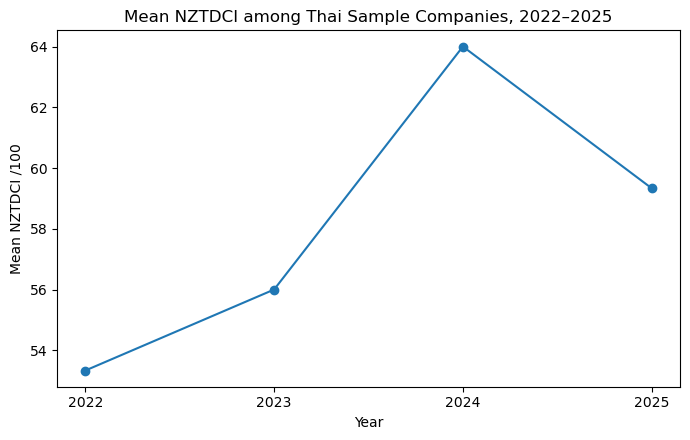

In [45]:
# ============================================================
# NZTDCI BY YEAR
# ============================================================
nztdci_by_year = (
    financial
    .groupby("Year")
    .agg(
        Mean_NZTDCI=("NZTDCI", "mean"),
        Median_NZTDCI=("NZTDCI", "median"),
        SD_NZTDCI=("NZTDCI", "std"),
        Min_NZTDCI=("NZTDCI", "min"),
        Max_NZTDCI=("NZTDCI", "max"),
        Mean_ROA_pct=("ROA_pct", "mean"),
        Mean_ROE_pct=("ROE_pct", "mean"),
    )
)

display(nztdci_by_year.round(3))

# Create a simple annual trend figure for the dissertation.
plt.figure(figsize=(7, 4.5))

plt.plot(
    nztdci_by_year.index,
    nztdci_by_year["Mean_NZTDCI"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Mean NZTDCI /100")
plt.title("Mean NZTDCI among Thai Sample Companies, 2022–2025")
plt.xticks([2022, 2023, 2024, 2025])
plt.tight_layout()

plt.savefig(
    "01_mean_NZTDCI_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [46]:
# ============================================================
# NZTDCI BY COMPANY
# ============================================================
nztdci_by_company = (
    financial
    .groupby("Company")
    .agg(
        Mean_NZTDCI=("NZTDCI", "mean"),
        Min_NZTDCI=("NZTDCI", "min"),
        Max_NZTDCI=("NZTDCI", "max"),
        Mean_ROA_pct=("ROA_pct", "mean"),
        Mean_ROE_pct=("ROE_pct", "mean"),
    )
    .sort_values(
        "Mean_NZTDCI",
        ascending=False
    )
)

display(nztdci_by_company.round(3))

,Mean_NZTDCI,Min_NZTDCI,Max_NZTDCI,Mean_ROA_pct,Mean_ROE_pct
Company,,,,,
DELTA,82.5,70,90,17.982,28.965
PTT,72.5,60,80,2.841,8.754
CPALL,70.0,50,90,2.266,18.254
KBANK,70.0,60,80,1.029,8.280
SCBX,70.0,70,70,1.243,9.083
BCP,67.5,50,80,2.951,12.285
BDMS,62.5,60,70,10.118,15.043
PTTEP,60.0,50,70,8.004,14.651
SCC,60.0,40,80,1.923,4.661


In [47]:
# ============================================================
# NZTDCI BY SECTOR
# ============================================================
nztdci_by_sector = (
    financial
    .groupby("Sector")
    .agg(
        N=("Company", "count"),
        Mean_NZTDCI=("NZTDCI", "mean"),
        Median_NZTDCI=("NZTDCI", "median"),
        Mean_ROA_pct=("ROA_pct", "mean"),
        Mean_ROE_pct=("ROE_pct", "mean"),
    )
    .sort_values(
        "Mean_NZTDCI",
        ascending=False
    )
)

display(nztdci_by_sector.round(3))


,N,Mean_NZTDCI,Median_NZTDCI,Mean_ROA_pct,Mean_ROE_pct
Sector,,,,,
Electronics,4,82.50,85.0,17.982,28.965
Financial Services,4,70.00,70.0,1.243,9.083
Retail,4,70.00,70.0,2.266,18.254
Healthcare,4,62.50,60.0,10.118,15.043
Energy,20,60.50,60.0,4.117,11.102
Materials,4,60.00,60.0,1.923,4.661
Property,4,57.50,60.0,5.351,16.628
Banking,8,53.75,55.0,0.965,7.942
Telecom,4,40.00,40.0,8.504,37.073


In [48]:
# ============================================================
# PREPARE FINAL CRITERION-LEVEL DATA
# ============================================================
coding = coding_raw.copy()

print("Coding_Final columns:")
print(list(coding.columns))

# Search for the final analytical score column.
possible_score_columns = [
    "Final Score",
    "Researcher Verified Final Score",
    "Resolved Final Score",
    "Score",
]

final_score_column = next(
    (
        col
        for col in possible_score_columns
        if col in coding.columns
    ),
    None
)

# If the exact expected label is absent, search for a unique column
# containing both the words 'final' and 'score'.
if final_score_column is None:
    final_candidates = [
        col
        for col in coding.columns
        if "final" in str(col).lower()
        and "score" in str(col).lower()
    ]

    if len(final_candidates) == 1:
        final_score_column = final_candidates[0]
    else:
        raise ValueError(
            "Could not identify a unique final score column.\n"
            f"Candidate columns: {final_candidates}"
        )

print("\nUsing final score column:", final_score_column)

# Restrict Coding_Final to the same 15 Thai companies used in regression.
thai_coding = coding[
    coding["Company"].isin(
        financial["Company"].unique()
    )
].copy()

print("Thai criterion-level observations:", len(thai_coding))

assert len(thai_coding) == 600, (
    f"Expected 600 Thai criterion observations, found {len(thai_coding)}."
)

thai_coding[final_score_column] = pd.to_numeric(
    thai_coding[final_score_column],
    errors="coerce"
)

assert thai_coding[final_score_column].notna().all(), (
    "Missing final criterion scores were detected."
)

criterion_frequencies = (
    thai_coding
    .groupby("Criterion")
    .agg(
        Observations=(final_score_column, "count"),
        Disclosed_Count=(final_score_column, "sum"),
        Disclosure_Rate=(final_score_column, "mean"),
    )
)

criterion_frequencies["Disclosure_Percent"] = (
    criterion_frequencies["Disclosure_Rate"] * 100
)

criterion_frequencies = (
    criterion_frequencies
    .sort_values(
        "Disclosure_Percent",
        ascending=False
    )
)

display(
    criterion_frequencies[
        [
            "Observations",
            "Disclosed_Count",
            "Disclosure_Percent",
        ]
    ].round(2)
)


Coding_Final columns:
['Type', 'Company', 'Year', 'Sector', 'Criterion', 'Criterion Name', 'Final Evidence', 'Report / Source', 'Page', 'Source URL', 'Final Score', 'Final Coding Rationale', 'Researcher Verified?', 'Verification Status']

Using final score column: Final Score
Thai criterion-level observations: 600


,Observations,Disclosed_Count,Disclosure_Percent
Criterion,,,
Q1,60,55,91.67
Q10,60,51,85.00
Q8,60,51,85.00
Q6,60,45,75.00
Q9,60,41,68.33
Q4,60,35,58.33
Q5,60,34,56.67
Q2,60,24,40.00
Q7,60,7,11.67


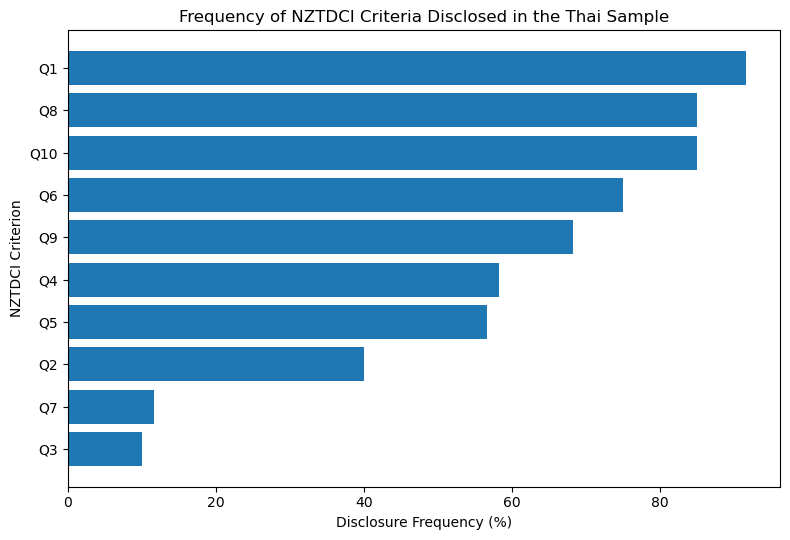

In [49]:
# ============================================================
# VISUALISE CRITERION DISCLOSURE FREQUENCIES
# ============================================================
plot_data = (
    criterion_frequencies
    .sort_values("Disclosure_Percent")
)

plt.figure(figsize=(8, 5.5))

plt.barh(
    plot_data.index.astype(str),
    plot_data["Disclosure_Percent"]
)

plt.xlabel("Disclosure Frequency (%)")
plt.ylabel("NZTDCI Criterion")
plt.title("Frequency of NZTDCI Criteria Disclosed in the Thai Sample")
plt.tight_layout()

plt.savefig(
    "02_criterion_disclosure_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [50]:
# ============================================================
# PEARSON CORRELATION MATRIX
# ============================================================
correlation_variables = [
    "NZTDCI",
    "ROA_pct",
    "ROE_pct",
    "Firm_Size",
    "Leverage",
]

correlation_matrix = (
    financial[correlation_variables]
    .corr(method="pearson")
)

display(correlation_matrix.round(3))

# Report the focal NZTDCI correlations with ROA and ROE.
for outcome in ["ROA_pct", "ROE_pct"]:

    r_value, p_value = stats.pearsonr(
        financial["NZTDCI"],
        financial[outcome]
    )

    print(
        f"NZTDCI vs {outcome}: "
        f"r = {r_value:.4f}, "
        f"p = {p_value:.4f}"
    )


,NZTDCI,ROA_pct,ROE_pct,Firm_Size,Leverage
NZTDCI,1.000,0.179,0.084,0.119,-0.040
ROA_pct,0.179,1.000,0.758,-0.573,-0.579
ROE_pct,0.084,0.758,1.000,-0.345,-0.088
Firm_Size,0.119,-0.573,-0.345,1.000,0.656
Leverage,-0.040,-0.579,-0.088,0.656,1.000


NZTDCI vs ROA_pct: r = 0.1794, p = 0.1703
NZTDCI vs ROE_pct: r = 0.0836, p = 0.5256


In [51]:
# ============================================================
# VARIANCE INFLATION FACTOR (VIF)
# ============================================================
vif_data = financial[
    [
        "NZTDCI_10",
        "Firm_Size",
        "Leverage",
    ]
].copy()

vif_data = sm.add_constant(vif_data)

vif_table = pd.DataFrame({
    "Variable": vif_data.columns,
    "VIF": [
        variance_inflation_factor(
            vif_data.values,
            i
        )
        for i in range(
            vif_data.shape[1]
        )
    ]
})

display(vif_table.round(3))


,Variable,VIF
0,const,149.521
1,NZTDCI_10,1.040
2,Firm_Size,1.824
3,Leverage,1.802


In [52]:
# ============================================================
# STAGED ROA REGRESSIONS
# ============================================================
roa_model_1 = smf.ols(
    "ROA_pct ~ NZTDCI_10",
    data=financial
).fit(cov_type="HC3")

roa_model_2 = smf.ols(
    "ROA_pct ~ NZTDCI_10 + Firm_Size + Leverage",
    data=financial
).fit(cov_type="HC3")

roa_model_3 = smf.ols(
    "ROA_pct ~ NZTDCI_10 + Firm_Size + Leverage + C(Year)",
    data=financial
).fit(cov_type="HC3")

roa_model_4 = smf.ols(
    "ROA_pct ~ NZTDCI_10 + Firm_Size + Leverage + C(Sector) + C(Year)",
    data=financial
).fit(cov_type="HC3")

print("MAIN BASELINE MODEL — ROA")
print(roa_model_4.summary())

MAIN BASELINE MODEL — ROA
                            OLS Regression Results                            
Dep. Variable:                ROA_pct   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     61.42
Date:                Sat, 22 Aug 2026   Prob (F-statistic):           1.81e-24
Time:                        16:12:52   Log-Likelihood:                -129.23
No. Observations:                  60   AIC:                             290.5
Df Residuals:                      44   BIC:                             324.0
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

In [53]:
# ============================================================
# STAGED ROE REGRESSIONS
# ============================================================
roe_model_1 = smf.ols(
    "ROE_pct ~ NZTDCI_10",
    data=financial
).fit(cov_type="HC3")

roe_model_2 = smf.ols(
    "ROE_pct ~ NZTDCI_10 + Firm_Size + Leverage",
    data=financial
).fit(cov_type="HC3")

roe_model_3 = smf.ols(
    "ROE_pct ~ NZTDCI_10 + Firm_Size + Leverage + C(Year)",
    data=financial
).fit(cov_type="HC3")

roe_model_4 = smf.ols(
    "ROE_pct ~ NZTDCI_10 + Firm_Size + Leverage + C(Sector) + C(Year)",
    data=financial
).fit(cov_type="HC3")

print("MAIN BASELINE MODEL — ROE")
print(roe_model_4.summary())

MAIN BASELINE MODEL — ROE
                            OLS Regression Results                            
Dep. Variable:                ROE_pct   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     33.23
Date:                Sat, 22 Aug 2026   Prob (F-statistic):           4.60e-19
Time:                        16:13:28   Log-Likelihood:                -180.15
No. Observations:                  60   AIC:                             392.3
Df Residuals:                      44   BIC:                             425.8
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

In [54]:
# ============================================================
# STAGED MODEL SUMMARY
# ============================================================
def extract_ols_nztdci(model, model_name, outcome):
    # Extract the coefficient, robust standard error, confidence interval,
    # p-value, and goodness-of-fit statistics for NZTDCI_10.
    term = "NZTDCI_10"
    ci = model.conf_int().loc[term]

    return {
        "Model": model_name,
        "Outcome": outcome,
        "N": int(model.nobs),
        "NZTDCI_Beta_per_10_points": model.params[term],
        "Robust_SE": model.bse[term],
        "p_value": model.pvalues[term],
        "CI95_Lower": ci.iloc[0],
        "CI95_Upper": ci.iloc[1],
        "R_squared": model.rsquared,
        "Adjusted_R_squared": model.rsquared_adj,
    }

staged_results = pd.DataFrame([
    extract_ols_nztdci(roa_model_1, "ROA Model 1: NZTDCI only", "ROA"),
    extract_ols_nztdci(roa_model_2, "ROA Model 2: + controls", "ROA"),
    extract_ols_nztdci(roa_model_3, "ROA Model 3: + year effects", "ROA"),
    extract_ols_nztdci(roa_model_4, "ROA Model 4: + sector/year effects", "ROA"),

    extract_ols_nztdci(roe_model_1, "ROE Model 1: NZTDCI only", "ROE"),
    extract_ols_nztdci(roe_model_2, "ROE Model 2: + controls", "ROE"),
    extract_ols_nztdci(roe_model_3, "ROE Model 3: + year effects", "ROE"),
    extract_ols_nztdci(roe_model_4, "ROE Model 4: + sector/year effects", "ROE"),
])

display(staged_results.round(4))


,Model,Outcome,N,NZTDCI_Beta_per_10_points,Robust_SE,p_value,CI95_Lower,CI95_Upper,R_squared,Adjusted_R_squared
0,ROA Model 1: NZTDCI only,ROA,60,0.4699,0.4461,0.2922,-0.4044,1.3442,0.0322,0.0155
1,ROA Model 2: + controls,ROA,60,0.5596,0.4191,0.1818,-0.2619,1.3811,0.4445,0.4147
2,ROA Model 3: + year effects,ROA,60,0.5520,0.4308,0.2001,-0.2924,1.3964,0.4550,0.3933
3,ROA Model 4: + sector/year effects,ROA,60,-0.0291,0.2141,0.8918,-0.4487,0.3905,0.8215,0.7606
4,ROE Model 1: NZTDCI only,ROE,60,0.4354,0.9413,0.6437,-1.4096,2.2804,0.0070,-0.0101
5,ROE Model 2: + controls,ROE,60,0.8305,0.8732,0.3416,-0.8810,2.5420,0.1774,0.1334
6,ROE Model 3: + year effects,ROE,60,0.7816,0.8710,0.3695,-0.9255,2.4887,0.1993,0.1086
7,ROE Model 4: + sector/year effects,ROE,60,-0.0341,0.5585,0.9512,-1.1287,1.0604,0.7537,0.6697


In [55]:
# ============================================================
# FIRM-CLUSTERED STANDARD ERRORS
# ============================================================
main_formula_roa = (
    "ROA_pct ~ NZTDCI_10 + Firm_Size + Leverage + C(Sector) + C(Year)"
)

main_formula_roe = (
    "ROE_pct ~ NZTDCI_10 + Firm_Size + Leverage + C(Sector) + C(Year)"
)

roa_clustered = smf.ols(
    main_formula_roa,
    data=financial
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": financial["Company"],
        "use_correction": True,
    }
)

roe_clustered = smf.ols(
    main_formula_roe,
    data=financial
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": financial["Company"],
        "use_correction": True,
    }
)

print("ROA — MAIN MODEL WITH FIRM-CLUSTERED STANDARD ERRORS")
print(roa_clustered.summary())

print("\n\nROE — MAIN MODEL WITH FIRM-CLUSTERED STANDARD ERRORS")
print(roe_clustered.summary())


ROA — MAIN MODEL WITH FIRM-CLUSTERED STANDARD ERRORS
                            OLS Regression Results                            
Dep. Variable:                ROA_pct   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     128.9
Date:                Sat, 22 Aug 2026   Prob (F-statistic):           8.97e-12
Time:                        16:14:37   Log-Likelihood:                -129.23
No. Observations:                  60   AIC:                             290.5
Df Residuals:                      44   BIC:                             324.0
Df Model:                          15                                         
Covariance Type:              cluster                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 15, but rank is 8
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 15, but rank is 8
  warnings.warn('covariance of constraints does not have full '


In [56]:
# ============================================================
# FIRM FIXED EFFECTS + YEAR FIXED EFFECTS
# ============================================================
panel_data = (
    financial
    .set_index(["Company", "Year"])
    .sort_index()
)

fe_roa = PanelOLS.from_formula(
    """
    ROA_pct
    ~ 1
    + NZTDCI_10
    + Firm_Size
    + Leverage
    + EntityEffects
    + TimeEffects
    """,
    data=panel_data,
    drop_absorbed=True
).fit(
    cov_type="clustered",
    cluster_entity=True,
    debiased=True
)

fe_roe = PanelOLS.from_formula(
    """
    ROE_pct
    ~ 1
    + NZTDCI_10
    + Firm_Size
    + Leverage
    + EntityEffects
    + TimeEffects
    """,
    data=panel_data,
    drop_absorbed=True
).fit(
    cov_type="clustered",
    cluster_entity=True,
    debiased=True
)

print("FIRM FE + YEAR FE — ROA")
print(fe_roa.summary)

print("\n\nFIRM FE + YEAR FE — ROE")
print(fe_roe.summary)


FIRM FE + YEAR FE — ROA
                          PanelOLS Estimation Summary                           
Dep. Variable:                ROA_pct   R-squared:                        0.4286
Estimator:                   PanelOLS   R-squared (Between):             -2.2818
No. Observations:                  60   R-squared (Within):               0.4535
Date:                Sat, Aug 22 2026   R-squared (Overall):             -1.8133
Time:                        16:15:04   Log-likelihood                   -108.48
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      9.7527
Entities:                          15   P-value                           0.0001
Avg Obs:                       4.0000   Distribution:                    F(3,39)
Min Obs:                       4.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             6.6335
    

In [58]:
# ============================================================
# RANDOM-EFFECTS SUPPLEMENTARY MODELS
# ============================================================
re_data = panel_data[
    [
        "ROA_pct",
        "ROE_pct",
        "NZTDCI_10",
        "Firm_Size",
        "Leverage",
    ]
].copy()

re_exog = sm.add_constant(
    re_data[
        [
            "NZTDCI_10",
            "Firm_Size",
            "Leverage",
        ]
    ]
)

re_roa = RandomEffects(
    re_data["ROA_pct"],
    re_exog
).fit(
    cov_type="robust"
)

re_roe = RandomEffects(
    re_data["ROE_pct"],
    re_exog
).fit(
    cov_type="robust"
)

print("RANDOM EFFECTS — ROA")
print(re_roa.summary)

print("\n\nRANDOM EFFECTS — ROE")
print(re_roe.summary)


RANDOM EFFECTS — ROA
                        RandomEffects Estimation Summary                        
Dep. Variable:                ROA_pct   R-squared:                        0.2972
Estimator:              RandomEffects   R-squared (Between):              0.1853
No. Observations:                  60   R-squared (Within):               0.3317
Date:                Sat, Aug 22 2026   R-squared (Overall):              0.2104
Time:                        16:15:35   Log-likelihood                   -125.47
Cov. Estimator:                Robust                                           
                                        F-statistic:                      7.8935
Entities:                          15   P-value                           0.0002
Avg Obs:                       4.0000   Distribution:                    F(3,56)
Min Obs:                       4.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             12.404
       

In [59]:
# ============================================================
# CREATE ONE-YEAR LAGGED NZTDCI
# ============================================================
lagged = financial.copy()

lagged["NZTDCI_10_lag1"] = (
    lagged
    .groupby("Company")["NZTDCI_10"]
    .shift(1)
)

lagged_regression = (
    lagged
    .dropna(
        subset=["NZTDCI_10_lag1"]
    )
    .copy()
)

print("Lagged-model observations:", len(lagged_regression))
print("Expected maximum observations: 45")

assert len(lagged_regression) == 45, (
    f"Expected 45 lagged observations but found {len(lagged_regression)}."
)

display(
    lagged_regression[
        [
            "Company",
            "Year",
            "NZTDCI_10_lag1",
            "ROA_pct",
            "ROE_pct",
        ]
    ].head()
)


Lagged-model observations: 45
Expected maximum observations: 45


,Company,Year,NZTDCI_10_lag1,ROA_pct,ROE_pct
1,ADVANC,2023,3.0,7.349776,33.002549
2,ADVANC,2024,5.0,7.918839,37.354043
3,ADVANC,2025,5.0,11.244711,46.855558
5,AOT,2023,1.0,4.633797,8.301546
6,AOT,2024,2.0,9.549157,16.346460


In [60]:
# ============================================================
# ESTIMATE LAGGED ROA AND ROE MODELS
# ============================================================
lagged_roa = smf.ols(
    """
    ROA_pct
    ~ NZTDCI_10_lag1
    + Firm_Size
    + Leverage
    + C(Sector)
    + C(Year)
    """,
    data=lagged_regression
).fit(
    cov_type="HC3"
)

lagged_roe = smf.ols(
    """
    ROE_pct
    ~ NZTDCI_10_lag1
    + Firm_Size
    + Leverage
    + C(Sector)
    + C(Year)
    """,
    data=lagged_regression
).fit(
    cov_type="HC3"
)

print("LAGGED NZTDCI MODEL — ROA")
print(lagged_roa.summary())

print("\n\nLAGGED NZTDCI MODEL — ROE")
print(lagged_roe.summary())


LAGGED NZTDCI MODEL — ROA
                            OLS Regression Results                            
Dep. Variable:                ROA_pct   R-squared:                       0.883
Model:                            OLS   Adj. R-squared:                  0.829
Method:                 Least Squares   F-statistic:                     84.86
Date:                Sat, 22 Aug 2026   Prob (F-statistic):           3.51e-20
Time:                        16:16:46   Log-Likelihood:                -85.302
No. Observations:                  45   AIC:                             200.6
Df Residuals:                      30   BIC:                             227.7
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

In [61]:
# ============================================================
# BREUSCH–PAGAN HETEROSKEDASTICITY TEST
# ============================================================
roa_standard_ols = smf.ols(
    main_formula_roa,
    data=financial
).fit()

roe_standard_ols = smf.ols(
    main_formula_roe,
    data=financial
).fit()

def run_breusch_pagan(model, outcome_name):
    # Return the four standard Breusch–Pagan test statistics.
    lm_stat, lm_p, f_stat, f_p = het_breuschpagan(
        model.resid,
        model.model.exog
    )

    return {
        "Outcome": outcome_name,
        "LM Statistic": lm_stat,
        "LM p-value": lm_p,
        "F Statistic": f_stat,
        "F p-value": f_p,
    }

bp_results = pd.DataFrame([
    run_breusch_pagan(
        roa_standard_ols,
        "ROA"
    ),
    run_breusch_pagan(
        roe_standard_ols,
        "ROE"
    ),
])

display(bp_results.round(4))


,Outcome,LM Statistic,LM p-value,F Statistic,F p-value
0,ROA,25.9213,0.0389,2.2312,0.0198
1,ROE,27.0495,0.0283,2.4080,0.0121


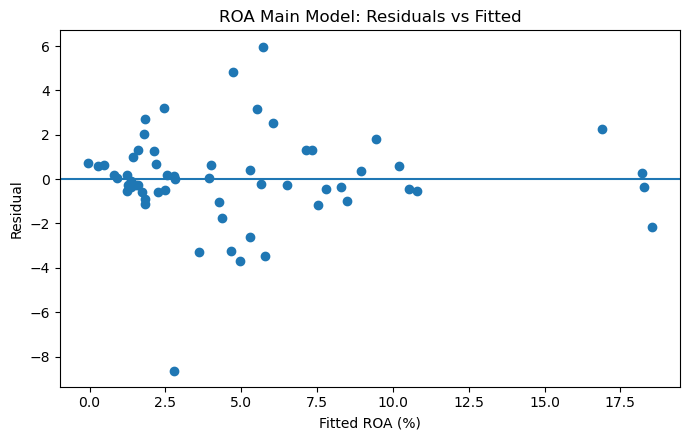

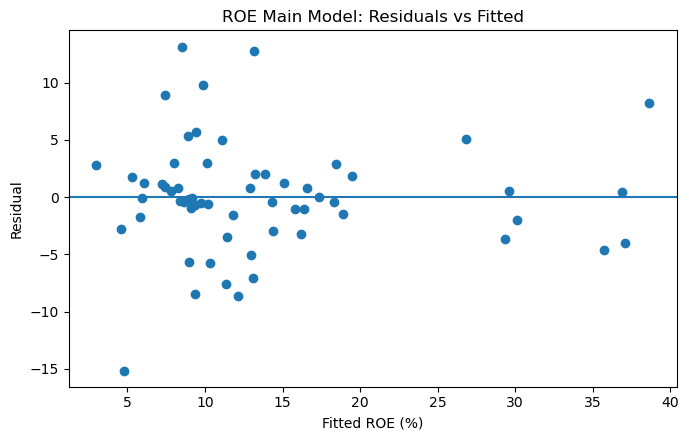

In [62]:
# ============================================================
# RESIDUAL-VERSUS-FITTED PLOTS
# ============================================================
plt.figure(figsize=(7, 4.5))

plt.scatter(
    roa_model_4.fittedvalues,
    roa_model_4.resid
)

plt.axhline(0)
plt.xlabel("Fitted ROA (%)")
plt.ylabel("Residual")
plt.title("ROA Main Model: Residuals vs Fitted")
plt.tight_layout()

plt.savefig(
    "03_ROA_residuals_vs_fitted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


plt.figure(figsize=(7, 4.5))

plt.scatter(
    roe_model_4.fittedvalues,
    roe_model_4.resid
)

plt.axhline(0)
plt.xlabel("Fitted ROE (%)")
plt.ylabel("Residual")
plt.title("ROE Main Model: Residuals vs Fitted")
plt.tight_layout()

plt.savefig(
    "04_ROE_residuals_vs_fitted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [63]:
# ============================================================
# JARQUE–BERA RESIDUAL DIAGNOSTIC
# ============================================================
roa_jb = stats.jarque_bera(
    roa_model_4.resid
)

roe_jb = stats.jarque_bera(
    roe_model_4.resid
)

print("ROA Jarque–Bera:", roa_jb)
print("ROE Jarque–Bera:", roe_jb)

ROA Jarque–Bera: SignificanceResult(statistic=np.float64(53.12843982533798), pvalue=np.float64(2.906068693163817e-12))
ROE Jarque–Bera: SignificanceResult(statistic=np.float64(5.983709835218383), pvalue=np.float64(0.05019424413070379))


In [64]:
# ============================================================
# COOK'S DISTANCE / INFLUENTIAL OBSERVATIONS
# ============================================================
roa_influence = (
    roa_standard_ols
    .get_influence()
)

roe_influence = (
    roe_standard_ols
    .get_influence()
)

cook_roa = (
    roa_influence
    .cooks_distance[0]
)

cook_roe = (
    roe_influence
    .cooks_distance[0]
)

influence_table = financial[
    [
        "Company",
        "Year",
        "NZTDCI",
        "ROA_pct",
        "ROE_pct",
    ]
].copy()

influence_table["CookD_ROA"] = cook_roa
influence_table["CookD_ROE"] = cook_roe

cook_threshold = 4 / len(financial)

influence_table["ROA_Flag_4_over_n"] = (
    influence_table["CookD_ROA"]
    > cook_threshold
)

influence_table["ROE_Flag_4_over_n"] = (
    influence_table["CookD_ROE"]
    > cook_threshold
)

print(
    "Indicative Cook's distance threshold (4/n):",
    round(cook_threshold, 4)
)

print("\nLargest ROA Cook's distance values:")
display(
    influence_table
    .sort_values(
        "CookD_ROA",
        ascending=False
    )
    .head(10)
)

print("\nLargest ROE Cook's distance values:")
display(
    influence_table
    .sort_values(
        "CookD_ROE",
        ascending=False
    )
    .head(10)
)


Indicative Cook's distance threshold (4/n): 0.0667

Largest ROA Cook's distance values:


,Company,Year,NZTDCI,ROA_pct,ROE_pct,CookD_ROA,CookD_ROE,ROA_Flag_4_over_n,ROE_Flag_4_over_n
4,AOT,2022,10,-5.852683,-10.378609,0.509453,0.286969,True,True
6,AOT,2024,20,9.549157,16.346460,0.155568,0.097363,True,True
7,AOT,2025,30,8.712324,14.208538,0.071136,0.036482,True,False
39,GULF,2025,50,11.712755,25.929654,0.059698,0.050004,False,False
33,GPSC,2023,40,1.285618,3.502875,0.038860,0.038641,False,False
35,GPSC,2025,50,2.316820,6.037820,0.037002,0.027695,False,False
28,DELTA,2022,80,19.142062,31.939845,0.033130,0.031186,False,False
13,BCP,2023,80,4.541486,19.631683,0.031933,0.074916,False,True
47,PTT,2025,80,2.688145,7.919493,0.031774,0.021558,False,False
30,DELTA,2024,90,16.379902,25.682850,0.030913,0.016232,False,False



Largest ROE Cook's distance values:


,Company,Year,NZTDCI,ROA_pct,ROE_pct,CookD_ROA,CookD_ROE,ROA_Flag_4_over_n,ROE_Flag_4_over_n
4,AOT,2022,10,-5.852683,-10.378609,0.509453,0.286969,True,True
6,AOT,2024,20,9.549157,16.346460,0.155568,0.097363,True,True
3,ADVANC,2025,30,11.244711,46.855558,0.022764,0.087010,False,True
13,BCP,2023,80,4.541486,19.631683,0.031933,0.074916,False,True
12,BCP,2022,50,5.662833,21.649409,0.023192,0.070614,False,True
39,GULF,2025,50,11.712755,25.929654,0.059698,0.050004,False,False
33,GPSC,2023,40,1.285618,3.502875,0.038860,0.038641,False,False
7,AOT,2025,30,8.712324,14.208538,0.071136,0.036482,True,False
28,DELTA,2022,80,19.142062,31.939845,0.033130,0.031186,False,False
34,GPSC,2024,70,1.415400,3.801010,0.027834,0.027808,False,False


In [65]:
# ============================================================
# CONSOLIDATED CONTEMPORANEOUS RESULTS
# ============================================================
def extract_panel_result(model, model_name, outcome, term="NZTDCI_10"):
    # Extract the focal coefficient from a linearmodels panel result.
    ci = model.conf_int().loc[term]

    return {
        "Model": model_name,
        "Outcome": outcome,
        "N": int(model.nobs),
        "NZTDCI_Beta": model.params[term],
        "SE": model.std_errors[term],
        "p_value": model.pvalues[term],
        "CI95_Lower": ci.iloc[0],
        "CI95_Upper": ci.iloc[1],
        "R_squared": model.rsquared,
    }

key_results = pd.DataFrame([
    extract_ols_nztdci(
        roa_model_4,
        "Main pooled OLS + sector/year effects (HC3)",
        "ROA"
    ),
    extract_ols_nztdci(
        roe_model_4,
        "Main pooled OLS + sector/year effects (HC3)",
        "ROE"
    ),
    extract_ols_nztdci(
        roa_clustered,
        "Pooled OLS + firm-clustered SE",
        "ROA"
    ),
    extract_ols_nztdci(
        roe_clustered,
        "Pooled OLS + firm-clustered SE",
        "ROE"
    ),
    extract_panel_result(
        fe_roa,
        "Firm FE + year FE",
        "ROA"
    ),
    extract_panel_result(
        fe_roe,
        "Firm FE + year FE",
        "ROE"
    ),
    extract_panel_result(
        re_roa,
        "Random effects (supplementary)",
        "ROA"
    ),
    extract_panel_result(
        re_roe,
        "Random effects (supplementary)",
        "ROE"
    ),
])

display(key_results.round(4))


,Model,Outcome,N,NZTDCI_Beta_per_10_points,Robust_SE,p_value,CI95_Lower,CI95_Upper,R_squared,Adjusted_R_squared,NZTDCI_Beta,SE
0,Main pooled OLS + sector/year effects (HC3),ROA,60,-0.0291,0.2141,0.8918,-0.4487,0.3905,0.8215,0.7606,NaN,NaN
1,Main pooled OLS + sector/year effects (HC3),ROE,60,-0.0341,0.5585,0.9512,-1.1287,1.0604,0.7537,0.6697,NaN,NaN
2,Pooled OLS + firm-clustered SE,ROA,60,-0.0291,0.1967,0.8823,-0.4147,0.3565,0.8215,0.7606,NaN,NaN
3,Pooled OLS + firm-clustered SE,ROE,60,-0.0341,0.4649,0.9414,-0.9453,0.8770,0.7537,0.6697,NaN,NaN
4,Firm FE + year FE,ROA,60,NaN,NaN,0.4426,-0.2218,0.4977,0.4286,NaN,0.1380,0.1779
5,Firm FE + year FE,ROE,60,NaN,NaN,0.5252,-0.5768,1.1121,0.3392,NaN,0.2676,0.4175
6,Random effects (supplementary),ROA,60,NaN,NaN,0.6231,-0.4601,0.7614,0.2972,NaN,0.1507,0.3049
7,Random effects (supplementary),ROE,60,NaN,NaN,0.7904,-1.1863,1.5512,0.0880,NaN,0.1825,0.6833


In [66]:
# ============================================================
# LAGGED MODEL RESULTS
# ============================================================
def extract_lagged_result(model, model_name, outcome):
    term = "NZTDCI_10_lag1"
    ci = model.conf_int().loc[term]

    return {
        "Model": model_name,
        "Outcome": outcome,
        "N": int(model.nobs),
        "Lagged_NZTDCI_Beta": model.params[term],
        "Robust_SE": model.bse[term],
        "p_value": model.pvalues[term],
        "CI95_Lower": ci.iloc[0],
        "CI95_Upper": ci.iloc[1],
        "R_squared": model.rsquared,
        "Adjusted_R_squared": model.rsquared_adj,
    }

lagged_results = pd.DataFrame([
    extract_lagged_result(
        lagged_roa,
        "One-year lagged NZTDCI",
        "ROA"
    ),
    extract_lagged_result(
        lagged_roe,
        "One-year lagged NZTDCI",
        "ROE"
    ),
])

display(lagged_results.round(4))


,Model,Outcome,N,Lagged_NZTDCI_Beta,Robust_SE,p_value,CI95_Lower,CI95_Upper,R_squared,Adjusted_R_squared
0,One-year lagged NZTDCI,ROA,45,-0.2184,0.1717,0.2034,-0.555,0.1181,0.8833,0.8289
1,One-year lagged NZTDCI,ROE,45,-0.5700,0.4964,0.2509,-1.543,0.4030,0.8243,0.7424


In [67]:
# ============================================================
# AUTOMATIC MAIN-MODEL INTERPRETATION
# ============================================================
def interpret_main_model(model, outcome):
    beta = model.params["NZTDCI_10"]
    p_value = model.pvalues["NZTDCI_10"]
    ci = model.conf_int().loc["NZTDCI_10"]

    direction_word = (
        "increase"
        if beta >= 0
        else "decrease"
    )

    significance_text = (
        "statistically significant at the 5% level"
        if p_value < 0.05
        else "not statistically significant at the 5% level"
    )

    print(
        f"{outcome}: A 10-point increase in NZTDCI is associated with "
        f"a {abs(beta):.3f} percentage-point {direction_word} in {outcome}, "
        f"holding firm size, leverage, sector and year effects constant. "
        f"The 95% confidence interval is "
        f"[{ci.iloc[0]:.3f}, {ci.iloc[1]:.3f}] "
        f"and p = {p_value:.3f}. "
        f"The association is {significance_text}."
    )

interpret_main_model(
    roa_model_4,
    "ROA"
)

print()

interpret_main_model(
    roe_model_4,
    "ROE"
)


ROA: A 10-point increase in NZTDCI is associated with a 0.029 percentage-point decrease in ROA, holding firm size, leverage, sector and year effects constant. The 95% confidence interval is [-0.449, 0.391] and p = 0.892. The association is not statistically significant at the 5% level.

ROE: A 10-point increase in NZTDCI is associated with a 0.034 percentage-point decrease in ROE, holding firm size, leverage, sector and year effects constant. The 95% confidence interval is [-1.129, 1.060] and p = 0.951. The association is not statistically significant at the 5% level.


In [68]:
# ============================================================
# EXPORT ANALYTICAL TABLES
# ============================================================
descriptive_statistics.to_csv(
    "05_descriptive_statistics.csv"
)

nztdci_by_year.to_csv(
    "06_NZTDCI_by_year.csv"
)

nztdci_by_company.to_csv(
    "07_NZTDCI_by_company.csv"
)

nztdci_by_sector.to_csv(
    "08_NZTDCI_by_sector.csv"
)

criterion_frequencies.to_csv(
    "09_criterion_frequencies.csv"
)

correlation_matrix.to_csv(
    "10_correlation_matrix.csv"
)

vif_table.to_csv(
    "11_VIF.csv",
    index=False
)

staged_results.to_csv(
    "12_staged_regression_results.csv",
    index=False
)

key_results.to_csv(
    "13_key_model_results.csv",
    index=False
)

lagged_results.to_csv(
    "14_lagged_model_results.csv",
    index=False
)

bp_results.to_csv(
    "15_breusch_pagan_results.csv",
    index=False
)

influence_table.to_csv(
    "16_influence_diagnostics.csv",
    index=False
)

# Save the exact 60-row regression dataset used by the models.
regression_data_used = financial[
    [
        "Company",
        "Year",
        "Sector",
        "NZTDCI",
        "NZTDCI_10",
        "ROA",
        "ROA_pct",
        "ROE",
        "ROE_pct",
        "Firm_Size",
        "Leverage",
    ]
].copy()

regression_data_used.to_csv(
    "17_regression_data_used.csv",
    index=False
)

# Create one combined Excel output workbook.
with pd.ExcelWriter(
    "18_regression_output_tables.xlsx",
    engine="openpyxl"
) as writer:

    regression_data_used.to_excel(
        writer,
        sheet_name="Data_Used",
        index=False
    )

    descriptive_statistics.to_excel(
        writer,
        sheet_name="Descriptives"
    )

    nztdci_by_year.to_excel(
        writer,
        sheet_name="NZTDCI_by_Year"
    )

    nztdci_by_company.to_excel(
        writer,
        sheet_name="NZTDCI_by_Company"
    )

    nztdci_by_sector.to_excel(
        writer,
        sheet_name="NZTDCI_by_Sector"
    )

    criterion_frequencies.to_excel(
        writer,
        sheet_name="Criterion_Frequencies"
    )

    correlation_matrix.to_excel(
        writer,
        sheet_name="Correlations"
    )

    vif_table.to_excel(
        writer,
        sheet_name="VIF",
        index=False
    )

    staged_results.to_excel(
        writer,
        sheet_name="Staged_Models",
        index=False
    )

    key_results.to_excel(
        writer,
        sheet_name="Key_Results",
        index=False
    )

    lagged_results.to_excel(
        writer,
        sheet_name="Lagged_Results",
        index=False
    )

    bp_results.to_excel(
        writer,
        sheet_name="Breusch_Pagan",
        index=False
    )

    influence_table.to_excel(
        writer,
        sheet_name="Influence",
        index=False
    )

print("All main tables exported successfully.")

All main tables exported successfully.


In [70]:
# ============================================================
# SAVE COMPLETE ORIGINAL STATISTICAL OUTPUT
# ============================================================
with open(
    "19_full_statistical_output.txt",
    "w",
    encoding="utf-8"
) as output_file:

    output_file.write(
        "NZTDCI × FINANCIAL PERFORMANCE — FULL STATISTICAL OUTPUT\n"
    )

    output_file.write(
        "=" * 90 + "\n\n"
    )

    for label, model in [
        ("ROA MODEL 1 — NZTDCI ONLY", roa_model_1),
        ("ROA MODEL 2 — + SIZE / LEVERAGE", roa_model_2),
        ("ROA MODEL 3 — + YEAR EFFECTS", roa_model_3),
        ("ROA MODEL 4 — + SECTOR / YEAR EFFECTS", roa_model_4),
        ("ROE MODEL 1 — NZTDCI ONLY", roe_model_1),
        ("ROE MODEL 2 — + SIZE / LEVERAGE", roe_model_2),
        ("ROE MODEL 3 — + YEAR EFFECTS", roe_model_3),
        ("ROE MODEL 4 — + SECTOR / YEAR EFFECTS", roe_model_4),
    ]:
        output_file.write(label + "\n")
        output_file.write(str(model.summary()))
        output_file.write("\n\n" + "=" * 90 + "\n\n")

    output_file.write(
        "ROA MAIN MODEL — FIRM-CLUSTERED STANDARD ERRORS\n"
    )
    output_file.write(str(roa_clustered.summary()))

    output_file.write(
        "\n\n" + "=" * 90 + "\n\n"
    )

    output_file.write(
        "ROE MAIN MODEL — FIRM-CLUSTERED STANDARD ERRORS\n"
    )
    output_file.write(str(roe_clustered.summary()))

    output_file.write(
        "\n\n" + "=" * 90 + "\n\n"
    )

    output_file.write(
        "ROA — FIRM FIXED EFFECTS + YEAR FIXED EFFECTS\n"
    )
    output_file.write(str(fe_roa.summary))

    output_file.write(
        "\n\n" + "=" * 90 + "\n\n"
    )

    output_file.write(
        "ROE — FIRM FIXED EFFECTS + YEAR FIXED EFFECTS\n"
    )
    output_file.write(str(fe_roe.summary))

    output_file.write(
        "\n\n" + "=" * 90 + "\n\n"
    )

    output_file.write(
        "ROA — RANDOM EFFECTS (SUPPLEMENTARY)\n"
    )
    output_file.write(str(re_roa.summary))

    output_file.write(
        "\n\n" + "=" * 90 + "\n\n"
    )

    output_file.write(
        "ROE — RANDOM EFFECTS (SUPPLEMENTARY)\n"
    )
    output_file.write(str(re_roe.summary))

    output_file.write(
        "\n\n" + "=" * 90 + "\n\n"
    )

    output_file.write(
        "ROA — ONE-YEAR LAGGED NZTDCI MODEL\n"
    )
    output_file.write(str(lagged_roa.summary()))

    output_file.write(
        "\n\n" + "=" * 90 + "\n\n"
    )

    output_file.write(
        "ROE — ONE-YEAR LAGGED NZTDCI MODEL\n"
    )
    output_file.write(str(lagged_roe.summary()))

print(
    "Full statistical output saved as 19_full_statistical_output.txt"
)

Full statistical output saved as 19_full_statistical_output.txt


## Part 6 — Compare International Benchmark

In [ ]:
# ------------------------------------------------------------
# LOAD THE COMPANY
# ------------------------------------------------------------

company_year = pd.read_excel(
    FINAL_FILE,
    sheet_name="CompanyYear_NZTDCI"
)

print("Total rows in CompanyYear_NZTDCI:", len(company_year))

display(company_year.head())

Total rows in CompanyYear_NZTDCI: 80


,Type,Company,Year,Sector,Final Raw Score /10,Final NZTDCI /100,Verification Status
0,International Benchmark,HEIDELBERG,2022,Materials,4,40,Completed
1,International Benchmark,HEIDELBERG,2023,Materials,5,50,Completed
2,International Benchmark,HEIDELBERG,2024,Materials,4,40,Completed
3,International Benchmark,HEIDELBERG,2025,Materials,4,40,Completed
4,International Benchmark,HOLCIM,2022,Materials / Construction,6,60,Completed


In [ ]:
# ------------------------------------------------------------
# IDENTIFY UNIQUE THAI COMPANIES IN THE DATASET
# ------------------------------------------------------------

thai_companies = financial["Company"].unique()

print("Thai companies:")
print(thai_companies)

print("\nNumber of Thai companies:", len(thai_companies))

Thai companies:
['ADVANC' 'AOT' 'BBL' 'BCP' 'BDMS' 'CPALL' 'CPN' 'DELTA' 'GPSC' 'GULF'
 'KBANK' 'PTT' 'PTTEP' 'SCBX' 'SCC']

Number of Thai companies: 15


In [ ]:
# ------------------------------------------------------------
# PREPARE THE COMPANY-YEAR BENCHMARK DATASET
# ------------------------------------------------------------

# Identify the NZTDCI column automatically
possible_nztdci_columns = [
    "Final NZTDCI /100",
    "NZTDCI /100",
    "NZTDCI"
]

nztdci_column = next(
    (
        col for col in possible_nztdci_columns
        if col in company_year.columns
    ),
    None
)

if nztdci_column is None:
    raise ValueError(
        "Could not identify the NZTDCI column.\n"
        f"Available columns: {list(company_year.columns)}"
    )

benchmark_data = company_year[
    [
        "Company",
        "Year",
        nztdci_column
    ]
].copy()

benchmark_data = benchmark_data.rename(
    columns={
        nztdci_column: "NZTDCI"
    }
)

In [78]:
# ------------------------------------------------------------
# ASSIGN GROUP LABELS FOR BENCHMARKING
# ------------------------------------------------------------
benchmark_data["Group"] = np.where(
    benchmark_data["Company"].isin(thai_companies),
    "Thai sample",
    "International benchmarks"
)

group_check = (
    benchmark_data
    .groupby("Group")
    .size()
)

print(group_check)

Group
International benchmarks    20
Thai sample                 60
dtype: int64


In [79]:
# ------------------------------------------------------------
# VERIFY BENCHMARK DATASET STRUCTURE
# ------------------------------------------------------------

assert (
    benchmark_data[
        benchmark_data["Group"] == "Thai sample"
    ].shape[0]
    == 60
), "Expected 60 Thai company-year observations."

assert (
    benchmark_data[
        benchmark_data["Group"] == "International benchmarks"
    ].shape[0]
    == 20
), "Expected 20 international benchmark observations."

assert (
    benchmark_data.loc[
        benchmark_data["Group"] == "International benchmarks",
        "Company"
    ].nunique()
    == 5
), "Expected five international benchmark companies."

print(
    "\nPASS — 60 Thai observations and "
    "20 international benchmark observations identified."
)


PASS — 60 Thai observations and 20 international benchmark observations identified.


In [80]:
# ------------------------------------------------------------
# SHOW INTERNATIONAL BENCHMARK COMPANIES
# ------------------------------------------------------------

international_company_names = (
    benchmark_data.loc[
        benchmark_data["Group"] == "International benchmarks",
        "Company"
    ]
    .drop_duplicates()
    .sort_values()
)

print("International benchmark companies detected:")

for company in international_company_names:
    print("-", company)

International benchmark companies detected:
- HEIDELBERG
- HOLCIM
- HSBC
- MAERSK
- UNILEVER


In [81]:
# ============================================================
# ANNUAL NZTDCI COMPARISON
# ============================================================
benchmark_year_summary = (
    benchmark_data
    .groupby(
        [
            "Group",
            "Year"
        ]
    )
    .agg(
        Mean_NZTDCI=("NZTDCI", "mean"),
        Median_NZTDCI=("NZTDCI", "median"),
        SD_NZTDCI=("NZTDCI", "std"),
        Min_NZTDCI=("NZTDCI", "min"),
        Max_NZTDCI=("NZTDCI", "max"),
        N=("NZTDCI", "count")
    )
    .reset_index()
)

display(
    benchmark_year_summary.round(2)
)

,Group,Year,Mean_NZTDCI,Median_NZTDCI,SD_NZTDCI,Min_NZTDCI,Max_NZTDCI,N
0,International benchmarks,2022,56.00,60.0,11.40,40,70,5
1,International benchmarks,2023,58.00,60.0,13.04,40,70,5
2,International benchmarks,2024,64.00,70.0,18.17,40,80,5
3,International benchmarks,2025,54.00,60.0,13.42,40,70,5
4,Thai sample,2022,53.33,50.0,21.27,10,80,15
5,Thai sample,2023,56.00,60.0,18.82,20,90,15
6,Thai sample,2024,64.00,70.0,16.39,20,90,15
7,Thai sample,2025,59.33,70.0,19.44,30,90,15


In [82]:
# Create a side-by-side annual comparison table.

benchmark_year_pivot = (
    benchmark_year_summary
    .pivot(
        index="Year",
        columns="Group",
        values="Mean_NZTDCI"
    )
)

benchmark_year_pivot[
    "Gap_International_minus_Thai"
] = (
    benchmark_year_pivot["International benchmarks"]
    - benchmark_year_pivot["Thai sample"]
)

display(
    benchmark_year_pivot.round(2)
)

Group,International benchmarks,Thai sample,Gap_International_minus_Thai
Year,,,
2022,56.0,53.33,2.67
2023,58.0,56.00,2.00
2024,64.0,64.00,0.00
2025,54.0,59.33,-5.33


In [83]:
# ============================================================
# INTERNATIONAL COMPANY-LEVEL SCORES
# ============================================================
international_only = benchmark_data[
    benchmark_data["Group"]
    == "International benchmarks"
].copy()

international_company_table = (
    international_only
    .pivot(
        index="Company",
        columns="Year",
        values="NZTDCI"
    )
)

international_company_table[
    "Four-year mean"
] = (
    international_company_table.mean(axis=1)
)

international_company_table = (
    international_company_table
    .sort_values(
        "Four-year mean",
        ascending=False
    )
)

display(
    international_company_table.round(2)
)

Year,2022,2023,2024,2025,Four-year mean
Company,,,,,
HSBC,60,60,80,70,67.5
MAERSK,70,70,70,60,67.5
UNILEVER,50,70,80,40,60.0
HOLCIM,60,40,50,60,52.5
HEIDELBERG,40,50,40,40,42.5


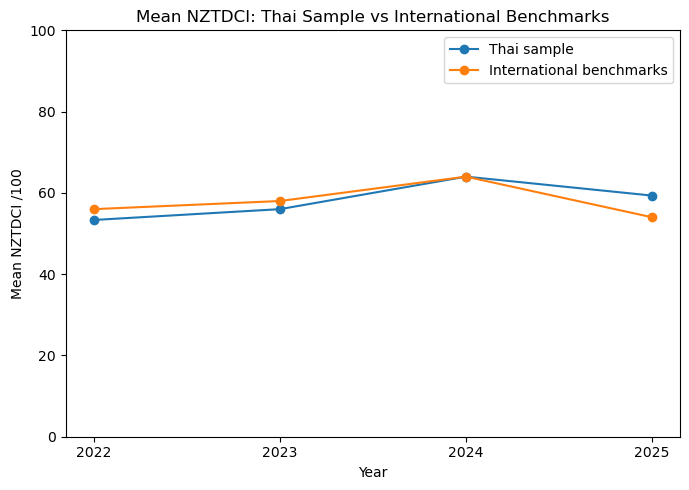

In [84]:
# ============================================================
# VISUALISE THAI VS INTERNATIONAL NZTDCI
# ============================================================
plot_data = (
    benchmark_year_summary
    .pivot(
        index="Year",
        columns="Group",
        values="Mean_NZTDCI"
    )
)

plt.figure(figsize=(7, 5))

plt.plot(
    plot_data.index,
    plot_data["Thai sample"],
    marker="o",
    label="Thai sample"
)

plt.plot(
    plot_data.index,
    plot_data["International benchmarks"],
    marker="o",
    label="International benchmarks"
)

plt.xlabel("Year")
plt.ylabel("Mean NZTDCI /100")

plt.title(
    "Mean NZTDCI: Thai Sample vs International Benchmarks"
)

plt.xticks(
    [
        2022,
        2023,
        2024,
        2025
    ]
)

plt.ylim(0, 100)

plt.legend()

plt.tight_layout()

plt.show()

# Part 7 — Visuals

In [90]:
# ============================================================
# SETUP — LOAD FINAL DATA
# ============================================================
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FINAL_FILE = Path("/Users/punch/Desktop/MSc Project /NZTDCI pre regression combine.xlsx")

financial_raw = pd.read_excel(FINAL_FILE, sheet_name="Financial_Data_Thai")
coding_raw = pd.read_excel(FINAL_FILE, sheet_name="Coding_Final")
company_year = pd.read_excel(FINAL_FILE, sheet_name="CompanyYear_NZTDCI")

financial = financial_raw.rename(columns={
    "Final NZTDCI /100": "NZTDCI",
    "NZTDCI /100": "NZTDCI",
    "ln(Total Assets)": "Firm_Size",
    "Firm Size": "Firm_Size",
}).copy()

financial = financial[
    ["Company","Year","Sector","NZTDCI","ROA","ROE","Firm_Size","Leverage"]
].copy()

for c in ["Year","NZTDCI","ROA","ROE","Firm_Size","Leverage"]:
    financial[c] = pd.to_numeric(financial[c], errors="coerce")

financial["ROA_pct"] = financial["ROA"] * 100
financial["ROE_pct"] = financial["ROE"] * 100
financial["NZTDCI_10"] = financial["NZTDCI"] / 10
financial = financial.sort_values(["Company","Year"]).reset_index(drop=True)

thai_companies = financial["Company"].unique()

nzcol = next(
    c for c in ["Final NZTDCI /100","NZTDCI /100","NZTDCI"]
    if c in company_year.columns
)

benchmark_data = company_year[
    ["Company","Year",nzcol]
].rename(columns={nzcol:"NZTDCI"}).copy()

benchmark_data["Group"] = np.where(
    benchmark_data["Company"].isin(thai_companies),
    "Thai sample",
    "International benchmarks"
)

score_col = None
for c in ["Final Score","Researcher Verified Final Score","Resolved Final Score","Score"]:
    if c in coding_raw.columns:
        score_col = c
        break

if score_col is None:
    score_col = [
        c for c in coding_raw.columns
        if "final" in c.lower() and "score" in c.lower()
    ][0]

coding_benchmark = coding_raw.copy()
coding_benchmark[score_col] = pd.to_numeric(
    coding_benchmark[score_col],
    errors="coerce"
)

coding_benchmark["Group"] = np.where(
    coding_benchmark["Company"].isin(thai_companies),
    "Thai sample",
    "International benchmarks"
)

coding_benchmark = coding_benchmark[
    coding_benchmark["Company"].isin(benchmark_data["Company"].unique())
].copy()

benchmark_year_summary = (
    benchmark_data.groupby(["Group","Year"])
    .agg(Mean_NZTDCI=("NZTDCI","mean"))
    .reset_index()
)

criterion_group_summary = (
    coding_benchmark.groupby(["Criterion","Group"])
    .agg(Disclosure_Rate=(score_col,"mean"))
    .reset_index()
)

criterion_group_summary["Disclosure_Percent"] = (
    criterion_group_summary["Disclosure_Rate"] * 100
)

criterion_comparison = criterion_group_summary.pivot(
    index="Criterion",
    columns="Group",
    values="Disclosure_Percent"
).reindex([f"Q{i}" for i in range(1,11)])

criterion_comparison["Gap_International_minus_Thai"] = (
    criterion_comparison["International benchmarks"]
    - criterion_comparison["Thai sample"]
)

print("Setup complete.")


Setup complete.


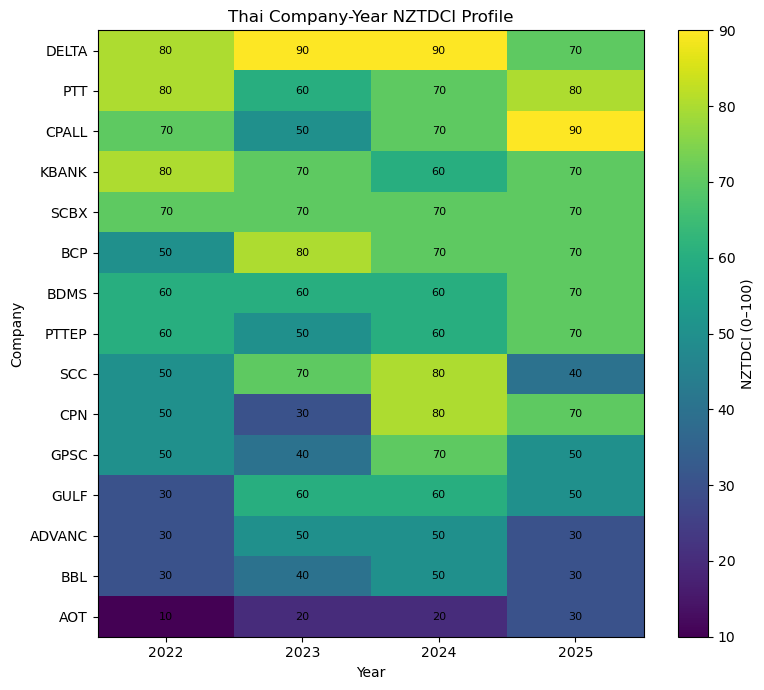

In [91]:
# ============================================================
# FIGURE 1 — THAI COMPANY-YEAR NZTDCI HEATMAP
# ============================================================
heat = benchmark_data[benchmark_data["Group"]=="Thai sample"].pivot(
    index="Company", columns="Year", values="NZTDCI"
)
heat["Mean"] = heat.mean(axis=1)
heat = heat.sort_values("Mean", ascending=False)
values = heat.drop(columns="Mean")

fig, ax = plt.subplots(figsize=(8,7))
image = ax.imshow(values.values, aspect="auto")
ax.set_xticks(range(len(values.columns)))
ax.set_xticklabels(values.columns.astype(int))
ax.set_yticks(range(len(values.index)))
ax.set_yticklabels(values.index)
ax.set_xlabel("Year")
ax.set_ylabel("Company")
ax.set_title("Thai Company-Year NZTDCI Profile")

for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        ax.text(j, i, f"{values.iloc[i,j]:.0f}",
                ha="center", va="center", fontsize=8)

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("NZTDCI (0–100)")
plt.tight_layout()
plt.savefig("Figure_1_Thai_NZTDCI_Heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


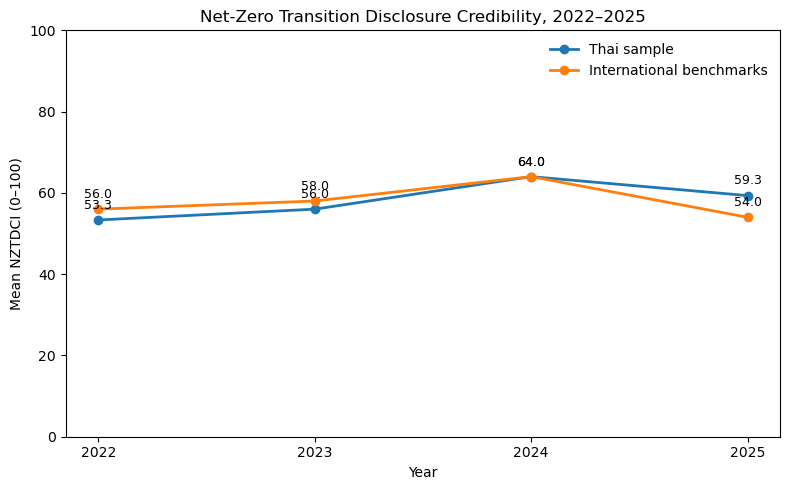

In [92]:
# ============================================================
# FIGURE 2 — THAI VS INTERNATIONAL NZTDCI TREND
# ============================================================
plot_data = benchmark_year_summary.pivot(
    index="Year", columns="Group", values="Mean_NZTDCI"
)

plt.figure(figsize=(8,5))

for group in ["Thai sample","International benchmarks"]:
    plt.plot(
        plot_data.index,
        plot_data[group],
        marker="o",
        linewidth=2,
        label=group
    )

    for year, value in plot_data[group].items():
        plt.annotate(
            f"{value:.1f}",
            (year,value),
            textcoords="offset points",
            xytext=(0,8),
            ha="center",
            fontsize=9
        )

plt.xlabel("Year")
plt.ylabel("Mean NZTDCI (0–100)")
plt.title("Net-Zero Transition Disclosure Credibility, 2022–2025")
plt.xticks([2022,2023,2024,2025])
plt.ylim(0,100)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("Figure_2_Thai_vs_International_Trend.png", dpi=300, bbox_inches="tight")
plt.show()


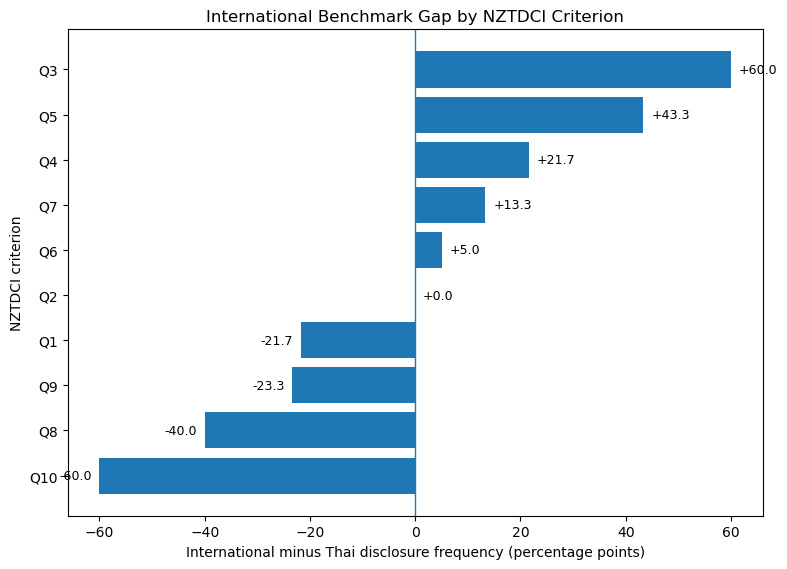

In [93]:
# ============================================================
# FIGURE 3 — INTERNATIONAL BENCHMARK GAP BY CRITERION
# ============================================================
gap = criterion_comparison["Gap_International_minus_Thai"].sort_values()

plt.figure(figsize=(8,5.8))
plt.barh(gap.index, gap.values)
plt.axvline(0, linewidth=1)

plt.xlabel("International minus Thai disclosure frequency (percentage points)")
plt.ylabel("NZTDCI criterion")
plt.title("International Benchmark Gap by NZTDCI Criterion")

for y_pos, value in enumerate(gap.values):
    ha = "left" if value >= 0 else "right"
    offset = 1.5 if value >= 0 else -1.5

    plt.text(
        value + offset,
        y_pos,
        f"{value:+.1f}",
        va="center",
        ha=ha,
        fontsize=9
    )

plt.tight_layout()
plt.savefig("Figure_3_Criterion_Benchmark_Gap.png", dpi=300, bbox_inches="tight")
plt.show()


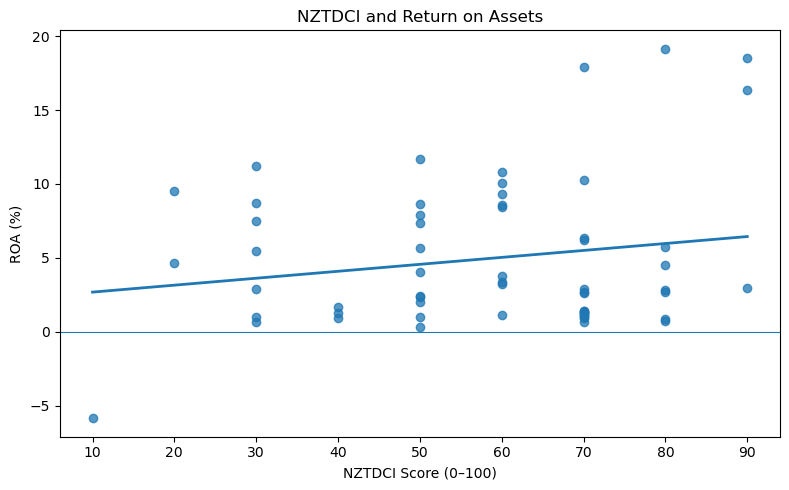

In [94]:
# ============================================================
# FIGURE 4 — NZTDCI VS ROA
# ============================================================
x = financial["NZTDCI"]
y = financial["ROA_pct"]

trend = np.polyfit(x, y, 1)
trend_line = np.poly1d(trend)
x_line = np.linspace(x.min(), x.max(), 100)

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.75)
plt.plot(x_line, trend_line(x_line), linewidth=2)
plt.axhline(0, linewidth=0.8)

plt.xlabel("NZTDCI Score (0–100)")
plt.ylabel("ROA (%)")
plt.title("NZTDCI and Return on Assets")
plt.tight_layout()

plt.savefig("Figure_4_NZTDCI_vs_ROA.png", dpi=300, bbox_inches="tight")
plt.show()


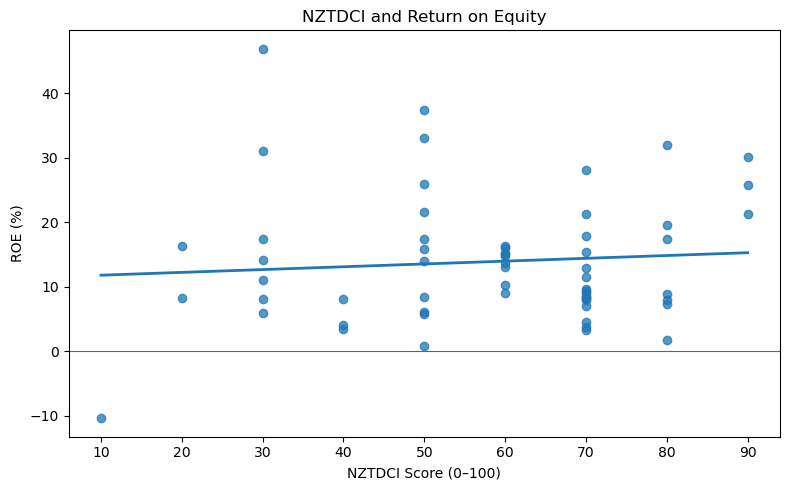

In [95]:
# ============================================================
# FIGURE 5 — NZTDCI VS ROE
# ============================================================
x = financial["NZTDCI"]
y = financial["ROE_pct"]

trend = np.polyfit(x, y, 1)
trend_line = np.poly1d(trend)
x_line = np.linspace(x.min(), x.max(), 100)

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.75)
plt.plot(x_line, trend_line(x_line), linewidth=2)
plt.axhline(0, linewidth=0.8)

plt.xlabel("NZTDCI Score (0–100)")
plt.ylabel("ROE (%)")
plt.title("NZTDCI and Return on Equity")
plt.tight_layout()

plt.savefig("Figure_5_NZTDCI_vs_ROE.png", dpi=300, bbox_inches="tight")
plt.show()


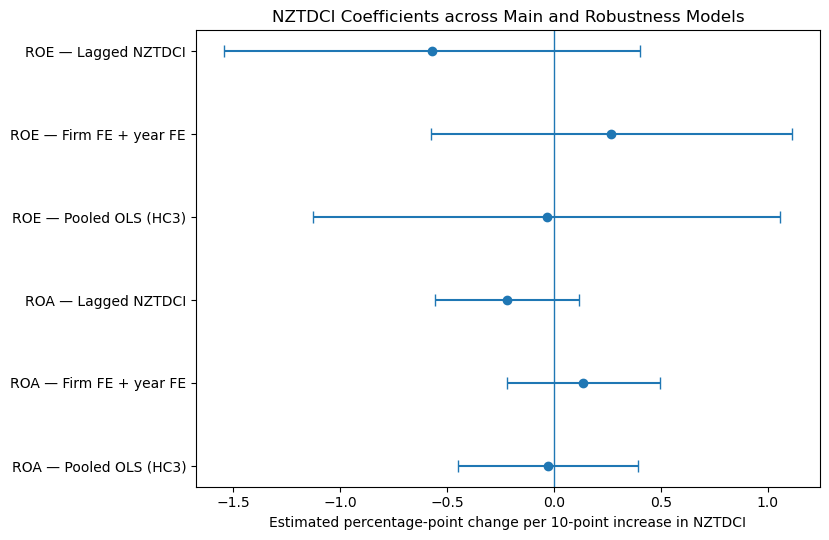

,Label,Beta,CI_Lower,CI_Upper
0,ROA — Pooled OLS (HC3),-0.0291,-0.4490,0.3910
1,ROA — Firm FE + year FE,0.1380,-0.2218,0.4977
2,ROA — Lagged NZTDCI,-0.2184,-0.5550,0.1180
3,ROE — Pooled OLS (HC3),-0.0341,-1.1290,1.0600
4,ROE — Firm FE + year FE,0.2676,-0.5768,1.1121
5,ROE — Lagged NZTDCI,-0.5700,-1.5430,0.4030


In [96]:
# ============================================================
# FIGURE 6 — REGRESSION COEFFICIENTS WITH 95% CONFIDENCE INTERVALS
# ============================================================
# These values come from the final executed regression output.
# They are entered explicitly so the figure exactly matches the
# final reported models without re-estimating the analysis.

coef_data = pd.DataFrame([
    ["ROA — Pooled OLS (HC3)", -0.0291, -0.4490, 0.3910],
    ["ROA — Firm FE + year FE", 0.1380, -0.2218, 0.4977],
    ["ROA — Lagged NZTDCI", -0.2184, -0.5550, 0.1180],
    ["ROE — Pooled OLS (HC3)", -0.0341, -1.1290, 1.0600],
    ["ROE — Firm FE + year FE", 0.2676, -0.5768, 1.1121],
    ["ROE — Lagged NZTDCI", -0.5700, -1.5430, 0.4030],
], columns=["Label","Beta","CI_Lower","CI_Upper"])

y_pos = np.arange(len(coef_data))

lower_error = coef_data["Beta"] - coef_data["CI_Lower"]
upper_error = coef_data["CI_Upper"] - coef_data["Beta"]

plt.figure(figsize=(8.4,5.5))

plt.errorbar(
    coef_data["Beta"],
    y_pos,
    xerr=[lower_error, upper_error],
    fmt="o",
    capsize=4
)

plt.axvline(0, linewidth=1)

plt.yticks(
    y_pos,
    coef_data["Label"]
)

plt.xlabel(
    "Estimated percentage-point change per 10-point increase in NZTDCI"
)

plt.ylabel("")
plt.title("NZTDCI Coefficients across Main and Robustness Models")
plt.tight_layout()

plt.savefig("Figure_6_Regression_Coefficients.png", dpi=300, bbox_inches="tight")
plt.show()

display(coef_data.round(4))
